
## 1 — OLS Regression: ε(t) ~ β·[SLP, T2m, u10, v10]

[REMOVE_BIAS=True]  bias rimosso: +3.698 cm  → ε ora centrata in 0
Total rows: 26076  →  Clean rows (no NaN): 25501
Coefficients (β): [-0.0156464  -0.02447097  0.02011789  0.00284016]
Intercept (β₀): -2.1406902723336025e-17
somma nan: SLP          0
t2m          0
u10          0
v10          0
error_m    575
dtype: int64

═══════════════════════════════════════
  Linear regression:  ε(t) ~ β·X(t)  (bias corretto: +3.698 cm)
  Station: København
═══════════════════════════════════════
  Intercept (β₀)  : -0.00000 m
  SLP (msl)    (β)  : -0.01565 m/σ
  T2m          (β)  : -0.02447 m/σ
  u10          (β)  : +0.02012 m/σ
  v10          (β)  : +0.00284 m/σ
───────────────────────────────────────
  R²              : 0.0884
  RMSE            : 12.00 cm
  Bias (ŷ−y)      : +0.00000000 cm
  Durbin-Watson   : 0.0580   (2=no autocorr, <2=pos, >2=neg)
═══════════════════════════════════════


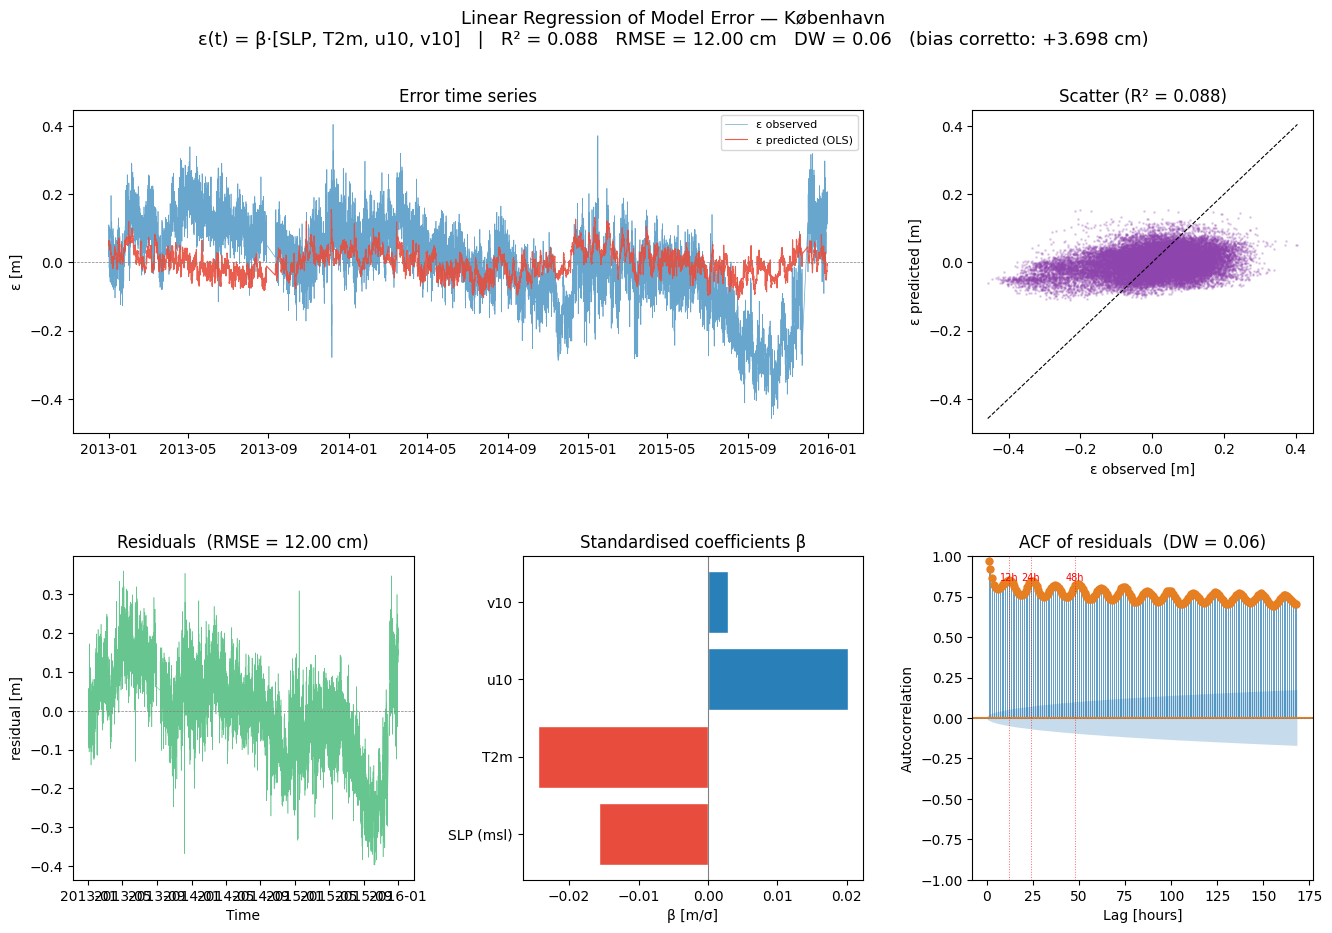

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson

# ════════════════════════════════════════════════════════════════════════
#  USER PARAMETERS — OLS
# ════════════════════════════════════════════════════════════════════════
REMOVE_BIAS = True   # True  → sottrae la media temporale di (Model − TG)
                     #          calcolata sul periodo 2013-2015 prima della regressione
                     # False → usa ε grezza (Model − TG_obs) senza correzione
# ════════════════════════════════════════════════════════════════════════

# ── Load København ──────────────────────────────────────────────────────
df = pd.read_parquet(
    "/Users/nicolocaron/Desktop/MASTER PROJECT/data/per_station/station_30336_Kobenhavn.parquet"
)

df_subset = df[
    df["time"].between("2013-01-01", "2015-12-31")
]

# ── Compute error ε(t) = Model − TG_obs ─────────────────────────────────
df_subset = df_subset.copy()
df_subset["error_m"] = df_subset["forcoast_p82_m"] - df_subset["tg_obs_m"]

# ── Bias correction ──────────────────────────────────────────────────────
mean_bias = df_subset["error_m"].mean()   # media temporale di ε sul periodo
if REMOVE_BIAS:
    df_subset["error_m"] = df_subset["error_m"] - mean_bias
    print(f"[REMOVE_BIAS=True]  bias rimosso: {mean_bias*100:+.3f} cm  → ε ora centrata in 0")
else:
    print(f"[REMOVE_BIAS=False] bias NON rimosso: {mean_bias*100:+.3f} cm")

# ── Features: atmospheric forcings ─────────────────────────────────────
features = ["SLP", "t2m", "u10", "v10"]
feature_labels = ["SLP (msl)", "T2m", "u10", "v10"]

# Drop rows where any feature or target is NaN
df_clean = df_subset[features + ["error_m", "time", "tg_obs_m", "forcoast_p82_m"]].dropna()
print(f"Total rows: {len(df_subset)}  →  Clean rows (no NaN): {len(df_clean)}")

X = df_clean[features].values
y = df_clean["error_m"].values

# Standardise features (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── OLS linear regression ───────────────────────────────────────────────
model = LinearRegression()
model.fit(X_scaled, y)

print(f"Coefficients (β): {model.coef_}")
print(f"Intercept (β₀): {model.intercept_}")

y_pred    = model.predict(X_scaled)
residuals = y - y_pred

rmse = np.sqrt(mean_squared_error(y, y_pred))
r2   = r2_score(y, y_pred)
bias = float(y_pred.mean() - y.mean())
dw   = durbin_watson(residuals)

print(f'somma nan: {df_subset[features + ["error_m"]].isna().sum()}')

bias_tag = f"(bias corretto: {mean_bias*100:+.3f} cm)" if REMOVE_BIAS else "(bias NON rimosso)"

# ── Print results ───────────────────────────────────────────────────────
print("\n═══════════════════════════════════════")
print(f"  Linear regression:  ε(t) ~ β·X(t)  {bias_tag}")
print("  Station: København")
print("═══════════════════════════════════════")
print(f"  Intercept (β₀)  : {model.intercept_:+.5f} m")
for name, coef in zip(feature_labels, model.coef_):
    print(f"  {name:12s} (β)  : {coef:+.5f} m/σ")
print("───────────────────────────────────────")
print(f"  R²              : {r2:.4f}")
print(f"  RMSE            : {rmse*100:.2f} cm")
print(f"  Bias (ŷ−y)      : {bias*100:+.8f} cm")
print(f"  Durbin-Watson   : {dw:.4f}   (2=no autocorr, <2=pos, >2=neg)")
print("═══════════════════════════════════════")

# ── Figure: 5 panels (2 top + 3 bottom) ────────────────────────────────
t = pd.to_datetime(df_clean["time"])

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    f"Linear Regression of Model Error — København\n"
    f"ε(t) = β·[SLP, T2m, u10, v10]   |   R² = {r2:.3f}   "
    f"RMSE = {rmse*100:.2f} cm   DW = {dw:.2f}   {bias_tag}",
    fontsize=13,
)

gs = fig.add_gridspec(2, 3, hspace=0.38, wspace=0.32)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(t, y,      color="#2980B9", lw=0.5, alpha=0.7, label="ε observed")
ax1.plot(t, y_pred, color="#E74C3C", lw=0.8, alpha=0.9, label="ε predicted (OLS)")
ax1.axhline(0, color="grey", lw=0.5, ls="--")
ax1.set_title("Error time series")
ax1.set_ylabel("ε [m]")
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[0, 2])
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax2.scatter(y, y_pred, s=1, alpha=0.2, color="#8E44AD")
ax2.plot(lims, lims, "k--", lw=0.8)
ax2.set_xlabel("ε observed [m]")
ax2.set_ylabel("ε predicted [m]")
ax2.set_title(f"Scatter (R² = {r2:.3f})")

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(t, residuals, color="#27AE60", lw=0.4, alpha=0.7)
ax3.axhline(0, color="grey", lw=0.5, ls="--")
ax3.set_title(f"Residuals  (RMSE = {rmse*100:.2f} cm)")
ax3.set_ylabel("residual [m]")
ax3.set_xlabel("Time")

ax4 = fig.add_subplot(gs[1, 1])
colors = ["#E74C3C" if c < 0 else "#2980B9" for c in model.coef_]
ax4.barh(feature_labels, model.coef_, color=colors, edgecolor="white")
ax4.axvline(0, color="grey", lw=0.8)
ax4.set_title("Standardised coefficients β")
ax4.set_xlabel("β [m/σ]")

ax5 = fig.add_subplot(gs[1, 2])
n_lags = min(168, len(residuals) // 10)
plot_acf(
    residuals,
    lags=n_lags,
    ax=ax5,
    alpha=0.05,
    color="#E67E22",
    vlines_kwargs={"lw": 0.5},
    zero=False,
    title=""
)
ax5.set_title(f"ACF of residuals  (DW = {dw:.2f})")
ax5.set_xlabel("Lag [hours]")
ax5.set_ylabel("Autocorrelation")
ax5.axhline(0, color="grey", lw=0.5, ls="--")

for lag, label in [(12, "12h"), (24, "24h"), (48, "48h")]:
    if lag <= n_lags:
        ax5.axvline(lag, color="red", lw=0.7, ls=":", alpha=0.6)
        ax5.text(lag, ax5.get_ylim()[1]*0.85, label,
                 fontsize=7, color="red", ha="center")

plt.show()


## 2 — MISO Lag Regression (L = 72 h)

[REMOVE_BIAS=True]  bias rimosso: +3.698 cm
Building lag matrix: 4 features × 241 lags = 964 columns ...
Rows after dropping NaN from lags: 25261  (dropped first 240 rows as expected)
Rows after dropping NaN from lags: 25261  (dropped first 240 rows as expected)



═══════════════════════════════════════════════
  MISO Lag Regression — København  (L = 240h)  (bias corretto: +3.698 cm)
═══════════════════════════════════════════════
  N features (total) : 964
  R²                 : 0.1946
  RMSE               : 11.32 cm
  Durbin-Watson      : 0.0594
═══════════════════════════════════════════════


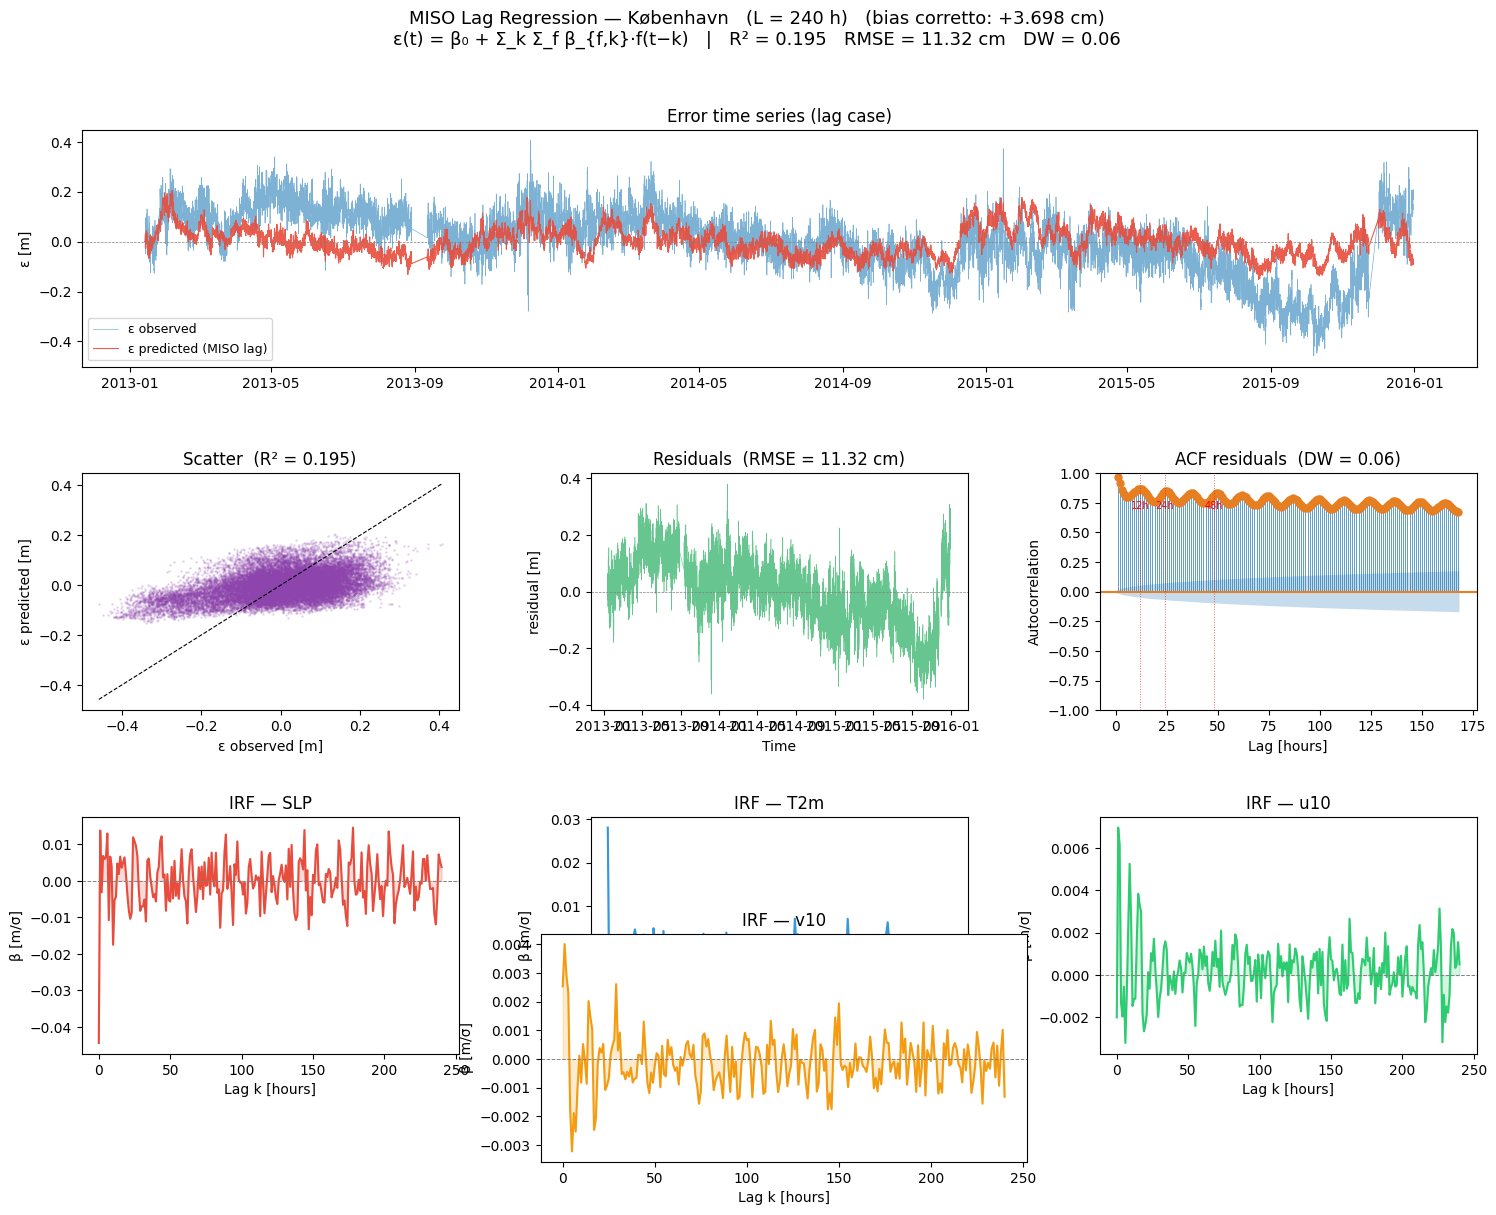

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson

# ════════════════════════════════════════════════════════════════════════
#  USER PARAMETERS — CASO CON LAG
# ════════════════════════════════════════════════════════════════════════
REMOVE_BIAS    = True   # True  → sottrae la media temporale di (Model − TG)
                        #          calcolata su 2013-2015 prima della regressione
                        # False → usa ε grezza senza correzione
L_lag          = 240
STATION_lag    = "København"
PARQUET_lag    = "/Users/nicolocaron/Desktop/MASTER PROJECT/data/per_station/station_30336_Kobenhavn.parquet"
FEATURES_lag   = ["SLP", "t2m", "u10", "v10"]
F_LABELS_lag   = ["SLP", "T2m", "u10", "v10"]
TARGET_COL_lag = "error_m"
# ════════════════════════════════════════════════════════════════════════

# 1) Load & compute error
df_lag_source = pd.read_parquet(PARQUET_lag)
df_subset_lag = df_lag_source[df_lag_source["time"].between("2013-01-01", "2015-12-31")].copy()
df_subset_lag[TARGET_COL_lag] = df_subset_lag["forcoast_p82_m"] - df_subset_lag["tg_obs_m"]

# ── Bias correction ──────────────────────────────────────────────────────
mean_bias_lag = df_subset_lag[TARGET_COL_lag].mean()
if REMOVE_BIAS:
    df_subset_lag[TARGET_COL_lag] = df_subset_lag[TARGET_COL_lag] - mean_bias_lag
    print(f"[REMOVE_BIAS=True]  bias rimosso: {mean_bias_lag*100:+.3f} cm")
else:
    print(f"[REMOVE_BIAS=False] bias NON rimosso: {mean_bias_lag*100:+.3f} cm")

bias_tag_lag = f"(bias corretto: {mean_bias_lag*100:+.3f} cm)" if REMOVE_BIAS else "(bias NON rimosso)"

# 2) Build lagged feature matrix
print(
    f"Building lag matrix: {len(FEATURES_lag)} features × {L_lag+1} lags = "
    f"{len(FEATURES_lag)*(L_lag+1)} columns ..."
)

lagged_columns_dict_lag = {}
for feat_lag in FEATURES_lag:
    for k_lag in range(0, L_lag + 1):
        col_name_lag = f"{feat_lag}_lag{k_lag:03d}"
        lagged_columns_dict_lag[col_name_lag] = df_subset_lag[feat_lag].shift(k_lag)

df_lag_features_lag = pd.DataFrame(lagged_columns_dict_lag)

# 3) Assemble model dataset and drop NaN
df_model_lag = pd.concat(
    [df_subset_lag[["time", TARGET_COL_lag]], df_lag_features_lag], axis=1
).dropna()

print(
    f"Rows after dropping NaN from lags: {len(df_model_lag)}  "
    f"(dropped first {L_lag} rows as expected)"
)

y_lag = df_model_lag[TARGET_COL_lag].values
X_raw_lag = df_model_lag[df_lag_features_lag.columns].values

# 4) Standardise
scaler_lag = StandardScaler()
X_scaled_lag = scaler_lag.fit_transform(X_raw_lag)

# 5) OLS
model_lag = LinearRegression()
model_lag.fit(X_scaled_lag, y_lag)
y_pred_lag = model_lag.predict(X_scaled_lag)
residuals_lag = y_lag - y_pred_lag

rmse_lag = np.sqrt(mean_squared_error(y_lag, y_pred_lag))
r2_lag = r2_score(y_lag, y_pred_lag)
dw_lag = durbin_watson(residuals_lag)

print("\n═══════════════════════════════════════════════")
print(f"  MISO Lag Regression — {STATION_lag}  (L = {L_lag}h)  {bias_tag_lag}")
print("═══════════════════════════════════════════════")
print(f"  N features (total) : {X_scaled_lag.shape[1]}")
print(f"  R²                 : {r2_lag:.4f}")
print(f"  RMSE               : {rmse_lag*100:.2f} cm")
print(f"  Durbin-Watson      : {dw_lag:.4f}")
print("═══════════════════════════════════════════════")

# 6) Impulse Response Functions (IRF)
n_feat_lag = len(FEATURES_lag)
n_lags_lag = L_lag + 1
beta_matrix_lag = model_lag.coef_.reshape(n_feat_lag, n_lags_lag)

# 7) Figure
t_lag = pd.to_datetime(df_model_lag["time"])

fig_lag = plt.figure(figsize=(18, 12))
fig_lag.suptitle(
    f"MISO Lag Regression — {STATION_lag}   (L = {L_lag} h)   {bias_tag_lag}\n"
    f"ε(t) = β₀ + Σ_k Σ_f β_{{f,k}}·f(t−k)   |   "
    f"R² = {r2_lag:.3f}   RMSE = {rmse_lag*100:.2f} cm   DW = {dw_lag:.2f}",
    fontsize=13,
)

gs_lag = fig_lag.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

ax1_lag = fig_lag.add_subplot(gs_lag[0, :])
ax1_lag.plot(t_lag, y_lag, color="#2980B9", lw=0.5, alpha=0.6, label="ε observed")
ax1_lag.plot(t_lag, y_pred_lag, color="#E74C3C", lw=0.8, alpha=0.9, label="ε predicted (MISO lag)")
ax1_lag.axhline(0, color="grey", lw=0.5, ls="--")
ax1_lag.set_title("Error time series (lag case)")
ax1_lag.set_ylabel("ε [m]")
ax1_lag.legend(fontsize=9)

ax2_lag = fig_lag.add_subplot(gs_lag[1, 0])
lims_lag = [min(y_lag.min(), y_pred_lag.min()), max(y_lag.max(), y_pred_lag.max())]
ax2_lag.scatter(y_lag, y_pred_lag, s=1, alpha=0.15, color="#8E44AD")
ax2_lag.plot(lims_lag, lims_lag, "k--", lw=0.8)
ax2_lag.set_xlabel("ε observed [m]")
ax2_lag.set_ylabel("ε predicted [m]")
ax2_lag.set_title(f"Scatter  (R² = {r2_lag:.3f})")

ax3_lag = fig_lag.add_subplot(gs_lag[1, 1])
ax3_lag.plot(t_lag, residuals_lag, color="#27AE60", lw=0.4, alpha=0.7)
ax3_lag.axhline(0, color="grey", lw=0.5, ls="--")
ax3_lag.set_title(f"Residuals  (RMSE = {rmse_lag*100:.2f} cm)")
ax3_lag.set_ylabel("residual [m]")
ax3_lag.set_xlabel("Time")

ax4_lag = fig_lag.add_subplot(gs_lag[1, 2])
n_lags_acf_lag = min(168, len(residuals_lag) // 10)
plot_acf(
    residuals_lag,
    lags=n_lags_acf_lag,
    ax=ax4_lag,
    alpha=0.05,
    color="#E67E22",
    vlines_kwargs={"lw": 0.5},
    zero=False,
    title="",
)
ax4_lag.set_title(f"ACF residuals  (DW = {dw_lag:.2f})")
ax4_lag.set_xlabel("Lag [hours]")
ax4_lag.set_ylabel("Autocorrelation")
for lag_mark_lag, label_mark_lag in [(12, "12h"), (24, "24h"), (48, "48h")]:
    if lag_mark_lag <= n_lags_acf_lag:
        ax4_lag.axvline(lag_mark_lag, color="red", lw=0.7, ls=":", alpha=0.6)
        ax4_lag.text(
            lag_mark_lag, 0.85, label_mark_lag,
            fontsize=7, color="red", ha="center",
            transform=ax4_lag.get_xaxis_transform(),
        )

lags_x_lag = np.arange(0, L_lag + 1)
colors_irf_lag = ["#E74C3C", "#3498DB", "#2ECC71", "#F39C12"]

for i_lag, (feat_name_lag, feat_label_lag, color_lag) in enumerate(zip(FEATURES_lag, F_LABELS_lag, colors_irf_lag)):
    if i_lag < 3:
        ax_irf_lag = fig_lag.add_subplot(gs_lag[2, i_lag])
    else:
        ax_irf_lag = fig_lag.add_axes([0.38, 0.02, 0.27, 0.19])

    ax_irf_lag.plot(lags_x_lag, beta_matrix_lag[i_lag], color=color_lag, lw=1.5)
    ax_irf_lag.fill_between(lags_x_lag, beta_matrix_lag[i_lag], alpha=0.2, color=color_lag)
    ax_irf_lag.axhline(0, color="grey", lw=0.7, ls="--")
    ax_irf_lag.set_title(f"IRF — {feat_label_lag}")
    ax_irf_lag.set_xlabel("Lag k [hours]")
    ax_irf_lag.set_ylabel("β [m/σ]")

plt.show()


✅ Usando variabili dalla cella MISO: København, L = 240 h
Stazione: København  |  3 eventi trovati (top 12 per picco TG)


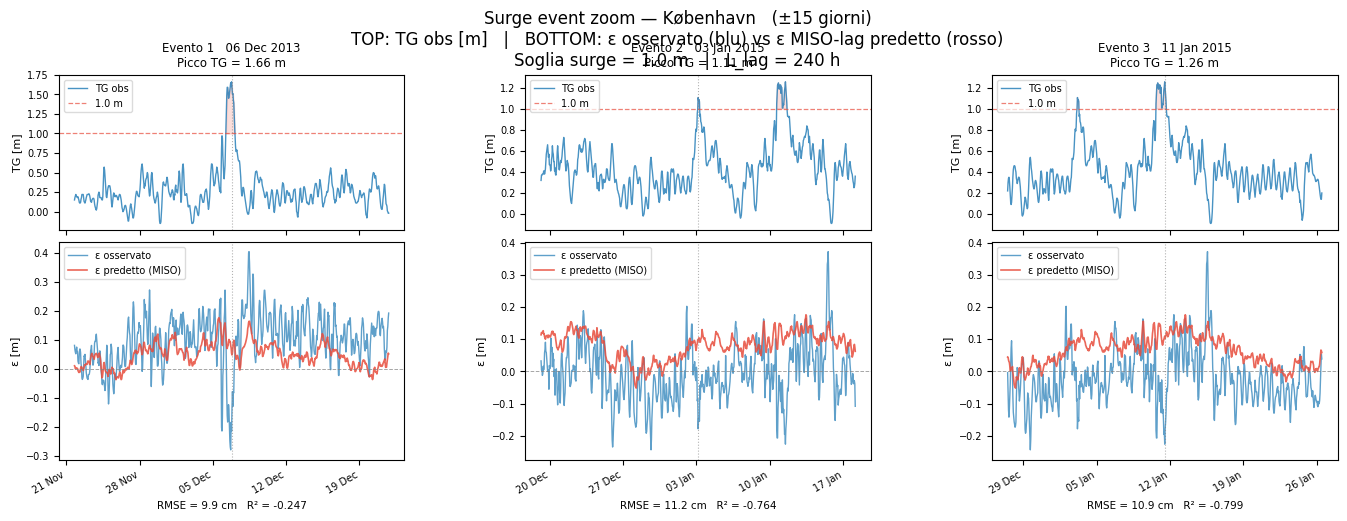

In [3]:

# ════════════════════════════════════════════════════════════════════════
#  SURGE EVENT ZOOM — ±15 days around each surge event
#
#  ⚙️  Configura solo PARQUET_ZOOM qui sotto, il resto è automatico.
#
#  Se la cella MISO (cella 4) NON è stata eseguita, questa cella
#  ricalcola automaticamente la regressione con parametri di default.
#
#  Layout: N_ROWS righe × 3 colonne.
#  Ogni pannello ha 2 assi sovrapposti:
#    TOP    — TG obs [m]  con shading delle ore di surge
#    BOTTOM — ε osservato (blu) vs ε predetto MISO-lag (rosso)
# ════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
import matplotlib.dates    as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# ── ⚙️  Parametri da cambiare ────────────────────────────────────────────
# Se la cella MISO è stata eseguita, usa i suoi valori; altrimenti fallback.
if "PARQUET_lag" not in dir():
    PARQUET_lag    = "/Users/nicolocaron/Desktop/MASTER PROJECT/data/per_station/station_30336_Kobenhavn.parquet"
    STATION_lag    = "København"
    L_lag          = 72
    FEATURES_lag   = ["SLP", "t2m", "u10", "v10"]
    TARGET_COL_lag = "error_m"
    REMOVE_BIAS_ZOOM = True
    print("⚠️  Cella MISO (cella 4) non eseguita — ricalcolo inline con parametri default")

    # Ricalcola MISO inline
    df_lag_source = pd.read_parquet(PARQUET_lag)
    df_subset_lag = df_lag_source[df_lag_source["time"].between("2013-01-01", "2015-12-31")].copy()
    df_subset_lag[TARGET_COL_lag] = df_subset_lag["forcoast_p82_m"] - df_subset_lag["tg_obs_m"]
    mean_bias_lag = df_subset_lag[TARGET_COL_lag].mean()
    if REMOVE_BIAS_ZOOM:
        df_subset_lag[TARGET_COL_lag] -= mean_bias_lag

    lagged = {}
    for feat in FEATURES_lag:
        for k in range(L_lag + 1):
            lagged[f"{feat}_lag{k:03d}"] = df_subset_lag[feat].shift(k)
    df_lag_features = pd.DataFrame(lagged)
    df_model_lag = pd.concat(
        [df_subset_lag[["time", TARGET_COL_lag]], df_lag_features], axis=1
    ).dropna()

    y_lag = df_model_lag[TARGET_COL_lag].values
    X_raw = df_model_lag[df_lag_features.columns].values
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X_raw)
    model = LinearRegression().fit(X_sc, y_lag)
    y_pred_lag = model.predict(X_sc)
    print(f"  MISO ricalcolato: R² = {r2_score(y_lag, y_pred_lag):.4f}  "
          f"RMSE = {np.sqrt(mean_squared_error(y_lag, y_pred_lag))*100:.2f} cm")
else:
    print(f"✅ Usando variabili dalla cella MISO: {STATION_lag}, L = {L_lag} h")

PARQUET_ZOOM   = PARQUET_lag   # usa la stessa stazione della cella MISO
                               # oppure metti un path esplicito, es:
                               # "/path/to/station_30336_Kobenhavn.parquet"

# ── Parametri visualizzazione ────────────────────────────────────────────
THRESH_ZOOM    = 1.00    # [m]   soglia surge
WINDOW_DAYS    = 15      # giorni prima/dopo il picco
GAP_ZOOM_H     = 12      # [h]   gap minimo per separare eventi distinti
EVENTS_PER_ROW = 3       # colonne per riga
MAX_EVENTS     = 12      # max eventi da mostrare (top per picco TG)

# ── Costruisci il dataframe "predetto" dalla cella MISO ─────────────────
#    df_model_lag ha: time, error_m, y_pred_lag (già calcolati)
df_pred = df_model_lag[["time"]].copy()
df_pred["time"]         = pd.to_datetime(df_pred["time"])
df_pred["error_obs_m"]  = y_lag          # ε osservato
df_pred["error_pred_m"] = y_pred_lag     # ε predetto dal modello MISO

# Aggiungi tg_obs_m da df_subset_lag (stessa base dati del fit)
df_pred = df_pred.merge(
    df_subset_lag[["time", "tg_obs_m"]].assign(
        time=pd.to_datetime(df_subset_lag["time"])
    ),
    on="time", how="left"
)

# ── Identifica eventi di surge sul dataset del modello ───────────────────
exc_z = df_pred[df_pred["tg_obs_m"] > THRESH_ZOOM][["time", "tg_obs_m"]].dropna().copy()
exc_z = exc_z.sort_values("time").reset_index(drop=True)
dt_z  = exc_z["time"].diff().dt.total_seconds().fillna(0) / 3600
exc_z["event_id"] = (dt_z > GAP_ZOOM_H).cumsum()

# Un record per evento: ora del picco TG
event_summary = (
    exc_z.groupby("event_id")
    .apply(lambda g: g.loc[g["tg_obs_m"].idxmax()])
    .reset_index(drop=True)
    .nlargest(MAX_EVENTS, "tg_obs_m")
    .sort_values("time")
    .reset_index(drop=True)
)

n_ev   = len(event_summary)
n_rows = int(np.ceil(n_ev / EVENTS_PER_ROW))
print(f"Stazione: {STATION_lag}  |  {n_ev} eventi trovati (top {MAX_EVENTS} per picco TG)")

# ── Costruisci la figura ─────────────────────────────────────────────────
fig_zoom = plt.figure(figsize=(EVENTS_PER_ROW * 5.5, n_rows * 5.0))
fig_zoom.suptitle(
    f"Surge event zoom — {STATION_lag}   (±{WINDOW_DAYS} giorni)\n"
    f"TOP: TG obs [m]   |   BOTTOM: ε osservato (blu) vs ε MISO-lag predetto (rosso)\n"
    f"Soglia surge = {THRESH_ZOOM} m   |   L_lag = {L_lag} h",
    fontsize=12, y=1.01,
)

outer_gs = mgridspec.GridSpec(
    n_rows, EVENTS_PER_ROW,
    figure=fig_zoom, hspace=0.55, wspace=0.35
)

for ev_idx, ev_row in event_summary.iterrows():
    peak_time = pd.to_datetime(ev_row["time"])
    peak_tg   = ev_row["tg_obs_m"]

    t_start = peak_time - pd.Timedelta(days=WINDOW_DAYS)
    t_end   = peak_time + pd.Timedelta(days=WINDOW_DAYS)

    win = df_pred[
        (df_pred["time"] >= t_start) &
        (df_pred["time"] <= t_end)
    ].copy()

    row_pos = ev_idx // EVENTS_PER_ROW
    col_pos = ev_idx  % EVENTS_PER_ROW

    inner_gs = mgridspec.GridSpecFromSubplotSpec(
        2, 1,
        subplot_spec=outer_gs[row_pos, col_pos],
        hspace=0.06,
        height_ratios=[1, 1.4],
    )
    ax_top = fig_zoom.add_subplot(inner_gs[0])
    ax_bot = fig_zoom.add_subplot(inner_gs[1], sharex=ax_top)

    # ── TOP: TG obs ──────────────────────────────────────────────────
    ax_top.plot(win["time"], win["tg_obs_m"],
                color="#2980B9", lw=1.0, alpha=0.85, label="TG obs")
    ax_top.axhline(THRESH_ZOOM, color="#E74C3C", lw=0.9, ls="--", alpha=0.7,
                   label=f"{THRESH_ZOOM} m")
    surge_mask = win["tg_obs_m"] > THRESH_ZOOM
    if surge_mask.any():
        ax_top.fill_between(
            win["time"], win["tg_obs_m"], THRESH_ZOOM,
            where=surge_mask, color="#E74C3C", alpha=0.18, zorder=0
        )
    ax_top.axvline(peak_time, color="grey", lw=0.8, ls=":", alpha=0.6)
    ax_top.set_ylabel("TG [m]", fontsize=8)
    ax_top.tick_params(labelbottom=False, labelsize=7)
    ax_top.set_title(
        f"Evento {ev_idx+1}   {peak_time.strftime('%d %b %Y')}\n"
        f"Picco TG = {peak_tg:.2f} m",
        fontsize=8.5,
    )
    ax_top.legend(fontsize=7, loc="upper left", framealpha=0.7)

    # ── BOTTOM: ε osservato vs predetto ──────────────────────────────
    ax_bot.plot(win["time"], win["error_obs_m"],
                color="#2980B9", lw=1.0, alpha=0.75, label="ε osservato")
    ax_bot.plot(win["time"], win["error_pred_m"],
                color="#E74C3C", lw=1.2, alpha=0.85, label="ε predetto (MISO)")
    ax_bot.axhline(0, color="grey", lw=0.7, ls="--", alpha=0.7)
    ax_bot.axvline(peak_time, color="grey", lw=0.8, ls=":", alpha=0.6)

    win_v = win.dropna(subset=["error_obs_m", "error_pred_m"])
    if len(win_v) > 1:
        rmse_w = np.sqrt(np.mean((win_v["error_obs_m"] - win_v["error_pred_m"])**2))
        r2_w   = r2_score(win_v["error_obs_m"], win_v["error_pred_m"])
        ax_bot.set_xlabel(f"RMSE = {rmse_w*100:.1f} cm   R² = {r2_w:.3f}", fontsize=7.5)
    else:
        ax_bot.set_xlabel("nessuna predizione disponibile", fontsize=7.5)

    ax_bot.set_ylabel("ε [m]", fontsize=8)
    ax_bot.tick_params(labelsize=7)
    ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax_bot.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    plt.setp(ax_bot.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax_bot.legend(fontsize=7, loc="upper left", framealpha=0.7)

# Nascondi pannelli inutilizzati
for k in range(n_ev, n_rows * EVENTS_PER_ROW):
    r_k, c_k = k // EVENTS_PER_ROW, k % EVENTS_PER_ROW
    fig_zoom.add_subplot(outer_gs[r_k, c_k]).set_visible(False)

plt.show()


## 3 — Detiding (utide) + MISO Regression Comparison

/Users/nicolocaron/Documents/GitHub/Master-tesi/.venv/lib/python3.13/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


STEP 1 — Loading data
  Rows loaded       : 26099
  Time range        : 2013-01-01 01:00:00 → 2015-12-31 23:00:00
  NaN in tg_obs_m   : 575
  NaN in model      : 0

STEP 2 — Preparing time array for utide  (DAYS)
  t_fit shape : (25524,)  (giorni da 2013-01-01 01:00:00)
  u_fit shape : (25524,)
  Time range  : 0.00 d → 1094.92 d  (1095 giorni ≈ 3.0 anni)

STEP 3 — Harmonic analysis with utide
solve: matrix prep ... solution ... done.

  Top 10 tidal constituents fitted on TG_obs:
Empty DataFrame
Columns: [name, amplitude, phase_deg]
Index: []

  ⚠️  M2 not found — check verbose output above

STEP 4 — Reconstructing tidal signal on all timesteps
solution ... done.

  Top 10 tidal constituents fitted on TG_obs:
Empty DataFrame
Columns: [name, amplitude, phase_deg]
Index: []

  ⚠️  M2 not found — check verbose output above

STEP 4 — Reconstructing tidal signal on all timesteps
  Tide signal  —  mean : +0.1347 m
                  std  : 0.1145 m
                  range: [-0.066, 0.333] m



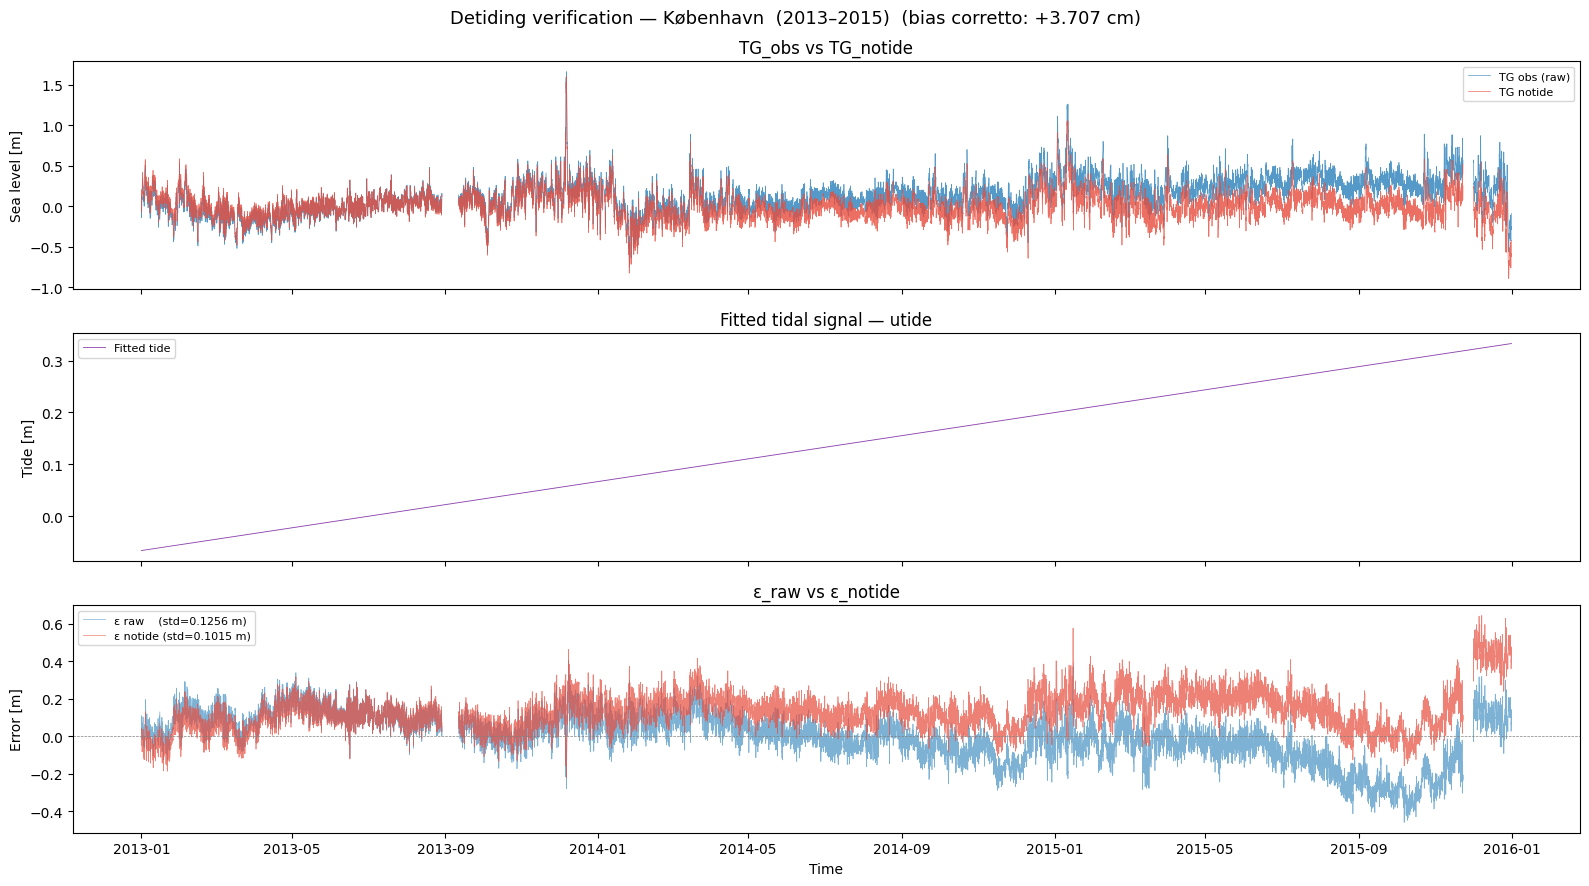

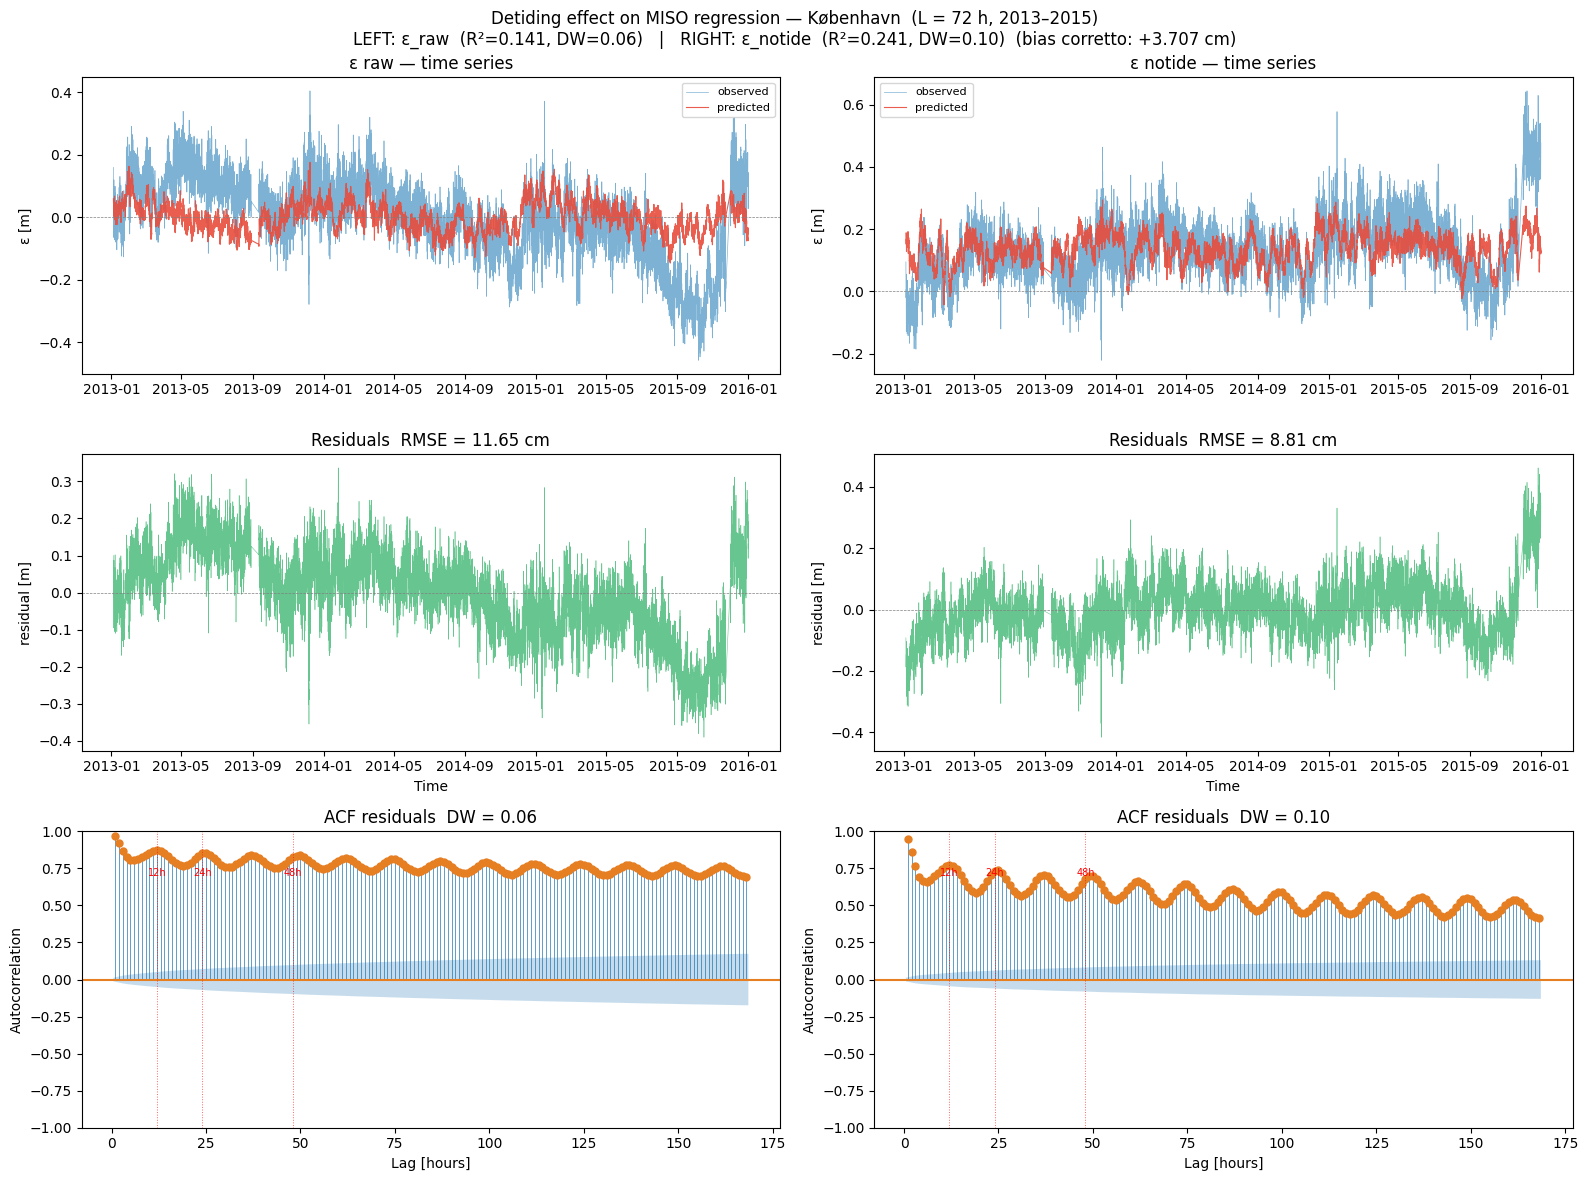

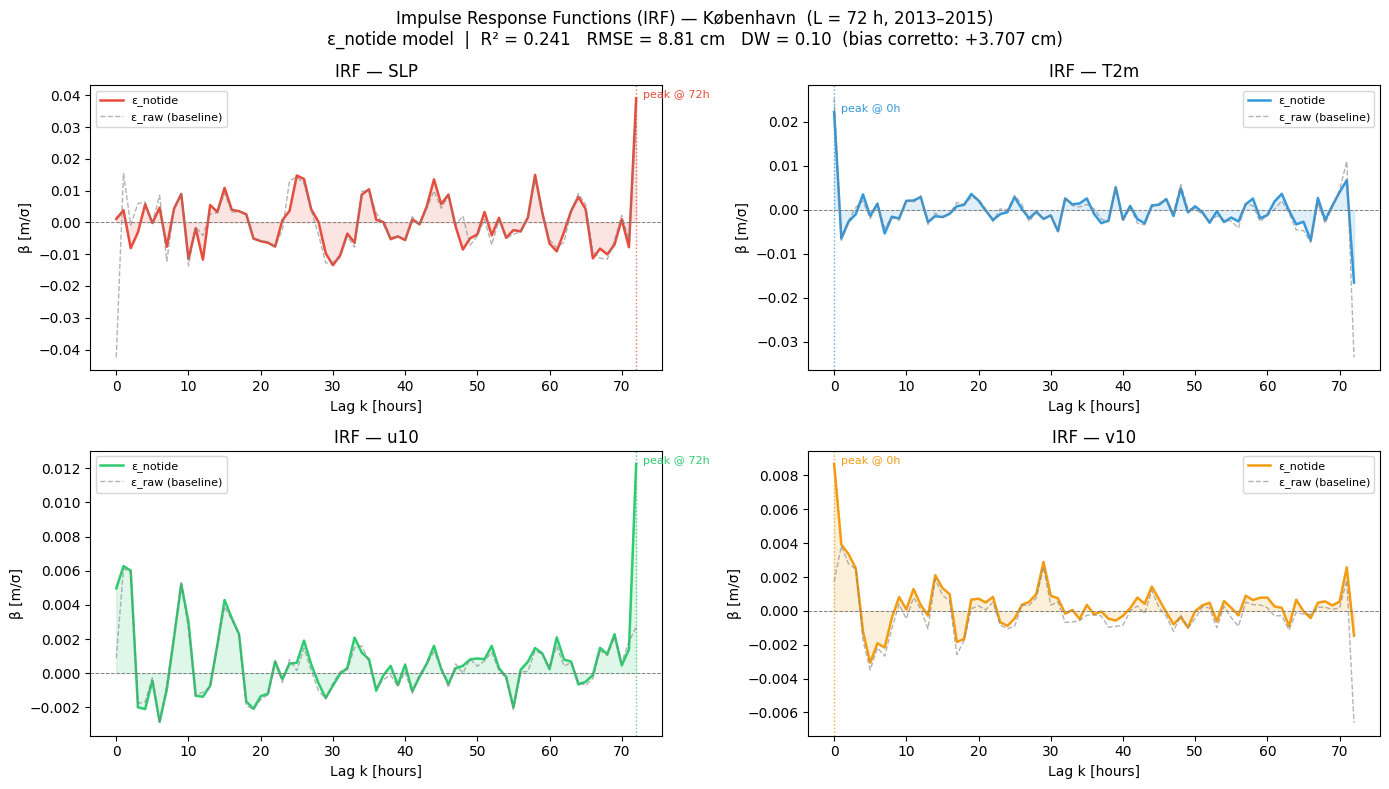

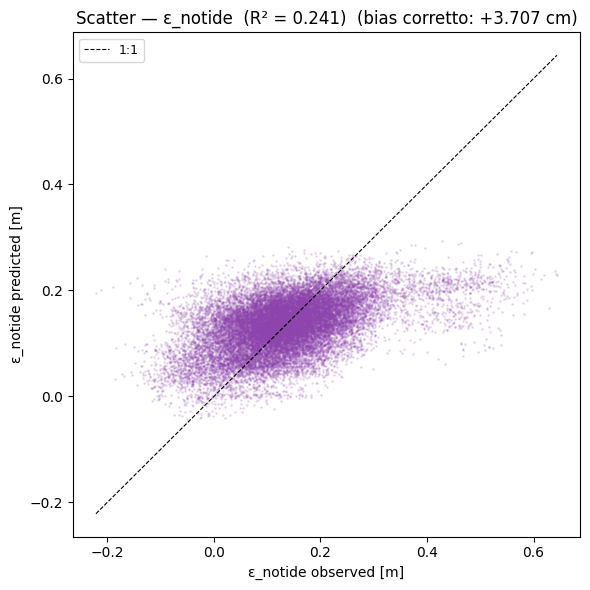


══════════════════════════════════════════════════
  FINAL SUMMARY — København  (L = 72 h, 2013–2015)
══════════════════════════════════════════════════
  ε_raw    →  R² = 0.1412  RMSE = 11.65 cm  DW = 0.058
  ε_notide →  R² = 0.2414  RMSE = 8.81 cm  DW = 0.102
  ΔR²      = +0.1002
  ΔRMSE    = -2.84 cm
  ΔDW      = +0.044
══════════════════════════════════════════════════
  (bias corretto: +3.707 cm)


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson
import utide

# ════════════════════════════════════════════════════════════════════════
#  USER PARAMETERS  ← cambia qui
# ════════════════════════════════════════════════════════════════════════
L        = 72        # numero di lag orari (es. 72 = 3 giorni)
LAT      = 55.7      # latitudine di København
STATION  = "København"
PARQUET  = "/Users/nicolocaron/Desktop/MASTER PROJECT/data/per_station/station_30336_Kobenhavn.parquet"
FEATURES = ["SLP", "t2m", "u10", "v10"]
F_LABELS = ["SLP", "T2m", "u10", "v10"]
CUTOFF   = "2015-12-31 23:00:00"   # ← usa dati solo fino a fine 2015

REMOVE_BIAS = True   # True  → sottrae la media temporale di (Model − TG)
                      # False → lascia l'errore invariato
# ════════════════════════════════════════════════════════════════════════


# ╔══════════════════════════════════════════════════════════════════════╗
# ║  STEP 1 — Carica il dataset (troncato al 2015)                      ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("=" * 60)
print("STEP 1 — Loading data")
print("=" * 60)

df_subset = pd.read_parquet(PARQUET)
df_subset = df_subset.sort_values("time").reset_index(drop=True)
df_subset = df_subset[df_subset["time"] <= CUTOFF].reset_index(drop=True)

print(f"  Rows loaded       : {len(df_subset)}")
print(f"  Time range        : {df_subset['time'].min()} → {df_subset['time'].max()}")
print(f"  NaN in tg_obs_m   : {df_subset['tg_obs_m'].isna().sum()}")
print(f"  NaN in model      : {df_subset['forcoast_p82_m'].isna().sum()}")


# ╔══════════════════════════════════════════════════════════════════════╗
# ║  STEP 2 — Converti il tempo in float GIORNI per utide               ║
# ╚══════════════════════════════════════════════════════════════════════╝
#
#  utide si aspetta il tempo in GIORNI (formato MATLAB datenum):
#    - t deve essere numpy 1D float (giorni da un'epoca)
#    - u deve essere numpy 1D float
#    - t e u devono avere ESATTAMENTE la stessa shape

print("\n" + "=" * 60)
print("STEP 2 — Preparing time array for utide  (DAYS)")
print("=" * 60)

t0       = df_subset["time"].min()    # epoca locale → t parte da 0
time_all = (df_subset["time"] - t0).dt.total_seconds().values / 86400.0  # GIORNI, float64

# Maschera: solo righe con TG_obs non-NaN
mask_tg = df_subset["tg_obs_m"].notna().values

# Applica la STESSA maschera a t e u → shape identica
t_fit = time_all[mask_tg]
u_fit = df_subset["tg_obs_m"].values[mask_tg]

print(f"  t_fit shape : {t_fit.shape}  (giorni da {t0})")
print(f"  u_fit shape : {u_fit.shape}")
print(f"  Time range  : {t_fit[0]:.2f} d → {t_fit[-1]:.2f} d  "
      f"({t_fit[-1]:.0f} giorni ≈ {t_fit[-1]/365.25:.1f} anni)")
assert t_fit.shape == u_fit.shape, "ERRORE: t e u hanno shape diverse!"


# ╔══════════════════════════════════════════════════════════════════════╗
# ║  STEP 3 — Fit armonico con utide                                    ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("\n" + "=" * 60)
print("STEP 3 — Harmonic analysis with utide")
print("=" * 60)

coef = utide.solve(
    t_fit,
    u_fit,
    lat=LAT,
    method="ols",
    conf_int="linear",
    verbose=True
)

# Stampa top 10 costituenti per ampiezza
df_const = pd.DataFrame({
    "name"      : coef.name,
    "amplitude" : coef.A,
    "phase_deg" : coef.g
}).sort_values("amplitude", ascending=False)

print("\n  Top 10 tidal constituents fitted on TG_obs:")
print(df_const.head(10).to_string(index=False))

# Controlla M2 specificamente
if "M2" in df_const["name"].values:
    m2 = df_const[df_const["name"] == "M2"].iloc[0]
    print(f"\n  ✅ M2 found:  amplitude = {m2['amplitude']:.4f} m   "
          f"phase = {m2['phase_deg']:.1f}°")
else:
    print("\n  ⚠️  M2 not found — check verbose output above")


# ╔══════════════════════════════════════════════════════════════════════╗
# ║  STEP 4 — Ricostruisce la marea su TUTTI i timestep                 ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("\n" + "=" * 60)
print("STEP 4 — Reconstructing tidal signal on all timesteps")
print("=" * 60)

# Ricostruisce su time_all (giorni) → include anche i gap del dataset
tide_fit    = utide.reconstruct(time_all, coef, verbose=False)
tide_signal = tide_fit.h    # numpy array 1D, shape = (len(df),)

print(f"  Tide signal  —  mean : {np.nanmean(tide_signal):+.4f} m")
print(f"                  std  : {np.nanstd(tide_signal):.4f} m")
print(f"                  range: [{tide_signal.min():.3f}, {tide_signal.max():.3f}] m")
print(f"\n  ✅ OK se std ~ 0.02–0.15 m (Baltico ha maree piccole)")
print(f"  ⚠️  BUG se std ~ 0 o se tide_signal è una retta")


# ╔══════════════════════════════════════════════════════════════════════╗
# ║  STEP 5 — Sottrai la marea e ricalcola gli errori                   ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("\n" + "=" * 60)
print("STEP 5 — Computing errors")
print("=" * 60)

df_subset["tide_utide_m"]   = tide_signal
df_subset["tg_notide_m"]    = df_subset["tg_obs_m"]       - tide_signal   # TG senza marea
df_subset["error_raw_m"]    = df_subset["forcoast_p82_m"] - df_subset["tg_obs_m"]      # ε totale
df_subset["error_notide_m"] = df_subset["forcoast_p82_m"] - df_subset["tg_notide_m"]   # ε senza marea

# ── Bias correction ──────────────────────────────────────────────────────
mean_bias_utide = df_subset["error_raw_m"].mean()
if REMOVE_BIAS:
    df_subset["error_raw_m"]    -= mean_bias_utide
    df_subset["error_notide_m"] -= mean_bias_utide
    print(f"[REMOVE_BIAS=True]  bias rimosso: {mean_bias_utide*100:+.3f} cm")
else:
    print(f"[REMOVE_BIAS=False] bias NON rimosso: {mean_bias_utide*100:+.3f} cm")
bias_tag_utide = f"(bias corretto: {mean_bias_utide*100:+.3f} cm)" if REMOVE_BIAS else "(bias NON rimosso)"

std_raw  = df_subset["error_raw_m"].std()
std_nd   = df_subset["error_notide_m"].std()

print(f"  ε_raw    std : {std_raw:.4f} m")
print(f"  ε_notide std : {std_nd:.4f} m")
if std_nd < std_raw:
    print(f"  ✅ Detiding riduce la varianza dell'errore di "
          f"{(std_raw - std_nd)*100:.2f} cm")
else:
    print(f"  ⚠️  ε_notide std > ε_raw std — controlla il detiding!")


# ╔══════════════════════════════════════════════════════════════════════╗
# ║  STEP 6 — Costruisci matrice dei lag (causalità rispettata)         ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("\n" + "=" * 60)
print(f"STEP 6 — Building lag matrix  (L = {L} h)")
print("=" * 60)

lag_cols = {}
for feat in FEATURES:
    for k in range(0, L + 1):
        lag_cols[f"{feat}_lag{k:03d}"] = df_subset[feat].shift(k)

df_lag   = pd.DataFrame(lag_cols)
df_model = pd.concat(
    [df_subset[["time", "error_notide_m", "error_raw_m"]], df_lag], axis=1
).dropna()

print(f"  Lag matrix shape  : {df_lag.shape[1]} cols  "
      f"({len(FEATURES)} features × {L+1} lags)")
print(f"  Rows after dropna : {len(df_model)}  "
      f"(prime {L} righe droppate per costruzione lag)")

y_notide = df_model["error_notide_m"].values
y_raw    = df_model["error_raw_m"].values
X_raw    = df_model[df_lag.columns].values


# ╔══════════════════════════════════════════════════════════════════════╗
# ║  STEP 7 — OLS baseline su ε_raw                                     ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("\n" + "=" * 60)
print("STEP 7 — OLS on ε_raw  (baseline)")
print("=" * 60)

scaler_raw = StandardScaler()
X_sc_raw   = scaler_raw.fit_transform(X_raw)
model_raw  = LinearRegression().fit(X_sc_raw, y_raw)
yp_raw     = model_raw.predict(X_sc_raw)
res_raw    = y_raw - yp_raw

r2_raw   = r2_score(y_raw, yp_raw)
rmse_raw = np.sqrt(mean_squared_error(y_raw, yp_raw))
dw_raw   = durbin_watson(res_raw)
print(f"  R² = {r2_raw:.4f}   RMSE = {rmse_raw*100:.2f} cm   DW = {dw_raw:.3f}")


# ╔══════════════════════════════════════════════════════════════════════╗
# ║  STEP 8 — OLS su ε_notide                                           ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("\n" + "=" * 60)
print("STEP 8 — OLS on ε_notide  (after detiding)")
print("=" * 60)

scaler_nd  = StandardScaler()
X_sc_nd    = scaler_nd.fit_transform(X_raw)
model_nd   = LinearRegression().fit(X_sc_nd, y_notide)
yp_notide  = model_nd.predict(X_sc_nd)
res_notide = y_notide - yp_notide

r2_nd   = r2_score(y_notide, yp_notide)
rmse_nd = np.sqrt(mean_squared_error(y_notide, yp_notide))
dw_nd   = durbin_watson(res_notide)
print(f"  R² = {r2_nd:.4f}   RMSE = {rmse_nd*100:.2f} cm   DW = {dw_nd:.3f}")

print("\n" + "─" * 40)
print(f"  ΔR²   = {r2_nd  - r2_raw:+.4f}   (notide − raw)")
print(f"  ΔRMSE = {(rmse_nd - rmse_raw)*100:+.2f} cm")
print(f"  ΔDW   = {dw_nd  - dw_raw:+.3f}")
print("─" * 40)


# ════════════════════════════════════════════════════════════════════════
#  FIGURE
# ════════════════════════════════════════════════════════════════════════
t_plot     = pd.to_datetime(df_model["time"])
t_full     = pd.to_datetime(df_subset["time"])
lags_x     = np.arange(0, L + 1)
beta_nd    = model_nd.coef_.reshape(len(FEATURES), L + 1)
beta_raw   = model_raw.coef_.reshape(len(FEATURES), L + 1)
colors_irf = ["#E74C3C", "#3498DB", "#2ECC71", "#F39C12"]
n_lags_acf = min(168, len(res_notide) // 10)


# ── FIGURA 1: Verifica detiding ─────────────────────────────────────────
fig1, ax1 = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
fig1.suptitle(f"Detiding verification — {STATION}  (2013–2015)  {bias_tag_utide}", fontsize=13)

ax1[0].plot(t_full, df_subset["tg_obs_m"],    color="#2980B9", lw=0.5,
            alpha=0.8, label="TG obs (raw)")
ax1[0].plot(t_full, df_subset["tg_notide_m"], color="#E74C3C", lw=0.5,
            alpha=0.8, label="TG notide")
ax1[0].set_ylabel("Sea level [m]"); ax1[0].legend(fontsize=8)
ax1[0].set_title("TG_obs vs TG_notide")

ax1[1].plot(t_full, tide_signal, color="#8E44AD", lw=0.6, label="Fitted tide")
ax1[1].set_ylabel("Tide [m]"); ax1[1].legend(fontsize=8)
ax1[1].set_title("Fitted tidal signal — utide")

ax1[2].plot(t_full, df_subset["error_raw_m"],    color="#2980B9", lw=0.5, alpha=0.6,
            label=f"ε raw    (std={std_raw:.4f} m)")
ax1[2].plot(t_full, df_subset["error_notide_m"], color="#E74C3C", lw=0.5, alpha=0.7,
            label=f"ε notide (std={std_nd:.4f} m)")
ax1[2].axhline(0, color="grey", lw=0.5, ls="--")
ax1[2].set_ylabel("Error [m]"); ax1[2].set_xlabel("Time")
ax1[2].legend(fontsize=8)
ax1[2].set_title("ε_raw vs ε_notide")

plt.tight_layout()
plt.show()


# ── FIGURA 2: RAW vs NOTIDE — confronto regressione ────────────────────
fig2, axes2 = plt.subplots(3, 2, figsize=(16, 12))
fig2.suptitle(
    f"Detiding effect on MISO regression — {STATION}  (L = {L} h, 2013–2015)\n"
    f"LEFT: ε_raw  (R²={r2_raw:.3f}, DW={dw_raw:.2f})   |   "
    f"RIGHT: ε_notide  (R²={r2_nd:.3f}, DW={dw_nd:.2f})  {bias_tag_utide}",
    fontsize=12
)

for ci, (y_, yp_, res_, lbl_, r2_, dw_) in enumerate([
    (y_raw,    yp_raw,    res_raw,    "ε raw",    r2_raw, dw_raw),
    (y_notide, yp_notide, res_notide, "ε notide", r2_nd,  dw_nd),
]):
    ax = axes2[0, ci]
    ax.plot(t_plot, y_,  color="#2980B9", lw=0.5, alpha=0.6, label="observed")
    ax.plot(t_plot, yp_, color="#E74C3C", lw=0.8, alpha=0.9, label="predicted")
    ax.axhline(0, color="grey", lw=0.5, ls="--")
    ax.set_title(f"{lbl_} — time series"); ax.set_ylabel("ε [m]")
    ax.legend(fontsize=8)

    ax = axes2[1, ci]
    ax.plot(t_plot, res_, color="#27AE60", lw=0.4, alpha=0.7)
    ax.axhline(0, color="grey", lw=0.5, ls="--")
    rmse_ = np.sqrt(mean_squared_error(y_, yp_))
    ax.set_title(f"Residuals  RMSE = {rmse_*100:.2f} cm")
    ax.set_ylabel("residual [m]"); ax.set_xlabel("Time")

    ax = axes2[2, ci]
    plot_acf(res_, lags=n_lags_acf, ax=ax, alpha=0.05,
             color="#E67E22", vlines_kwargs={"lw": 0.5}, zero=False, title="")
    ax.set_title(f"ACF residuals  DW = {dw_:.2f}")
    ax.set_xlabel("Lag [hours]"); ax.set_ylabel("Autocorrelation")
    for lag, lbl in [(12, "12h"), (24, "24h"), (48, "48h")]:
        if lag <= n_lags_acf:
            ax.axvline(lag, color="red", lw=0.7, ls=":", alpha=0.6)
            ax.text(lag, 0.85, lbl, fontsize=7, color="red", ha="center",
                    transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()


# ── FIGURA 3: Impulse Response Functions — notide ───────────────────────
fig3, axes3 = plt.subplots(2, 2, figsize=(14, 8))
fig3.suptitle(
    f"Impulse Response Functions (IRF) — {STATION}  (L = {L} h, 2013–2015)\n"
    f"ε_notide model  |  R² = {r2_nd:.3f}   RMSE = {rmse_nd*100:.2f} cm   "
    f"DW = {dw_nd:.2f}  {bias_tag_utide}",
    fontsize=12
)
axes3 = axes3.flatten()

for i, (feat, label, col) in enumerate(zip(FEATURES, F_LABELS, colors_irf)):
    ax = axes3[i]
    ax.plot(lags_x, beta_nd[i],  color=col,    lw=1.8, label="ε_notide")
    ax.plot(lags_x, beta_raw[i], color="grey", lw=1.0, ls="--",
            alpha=0.6, label="ε_raw (baseline)")
    ax.fill_between(lags_x, beta_nd[i], alpha=0.15, color=col)
    ax.axhline(0, color="grey", lw=0.7, ls="--")

    k_max = int(np.argmax(np.abs(beta_nd[i])))
    ax.axvline(k_max, color=col, lw=1.0, ls=":", alpha=0.8)
    ax.text(k_max + 1, beta_nd[i][k_max], f"peak @ {k_max}h",
            fontsize=8, color=col)

    ax.set_title(f"IRF — {label}")
    ax.set_xlabel("Lag k [hours]")
    ax.set_ylabel("β [m/σ]")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# ── FIGURA 4: Scatter ε_notide osservato vs predetto ────────────────────
fig4, ax4 = plt.subplots(1, 1, figsize=(6, 6))
lims = [min(y_notide.min(), yp_notide.min()),
        max(y_notide.max(), yp_notide.max())]
ax4.scatter(y_notide, yp_notide, s=1, alpha=0.15, color="#8E44AD")
ax4.plot(lims, lims, "k--", lw=0.8, label="1:1")
ax4.set_xlabel("ε_notide observed [m]")
ax4.set_ylabel("ε_notide predicted [m]")
ax4.set_title(f"Scatter — ε_notide  (R² = {r2_nd:.3f})  {bias_tag_utide}")
ax4.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\n{'═'*50}")
print(f"  FINAL SUMMARY — {STATION}  (L = {L} h, 2013–2015)")
print(f"{'═'*50}")
print(f"  ε_raw    →  R² = {r2_raw:.4f}  RMSE = {rmse_raw*100:.2f} cm  DW = {dw_raw:.3f}")
print(f"  ε_notide →  R² = {r2_nd:.4f}  RMSE = {rmse_nd*100:.2f} cm  DW = {dw_nd:.3f}")
print(f"  ΔR²      = {r2_nd - r2_raw:+.4f}")
print(f"  ΔRMSE    = {(rmse_nd - rmse_raw)*100:+.2f} cm")
print(f"  ΔDW      = {dw_nd - dw_raw:+.3f}")
print(f"{'═'*50}")
print(f"  {bias_tag_utide}")


## 4 — Threshold Exceedance Analysis

[REMOVE_BIAS=True]  Gedser bias: +6.147 cm


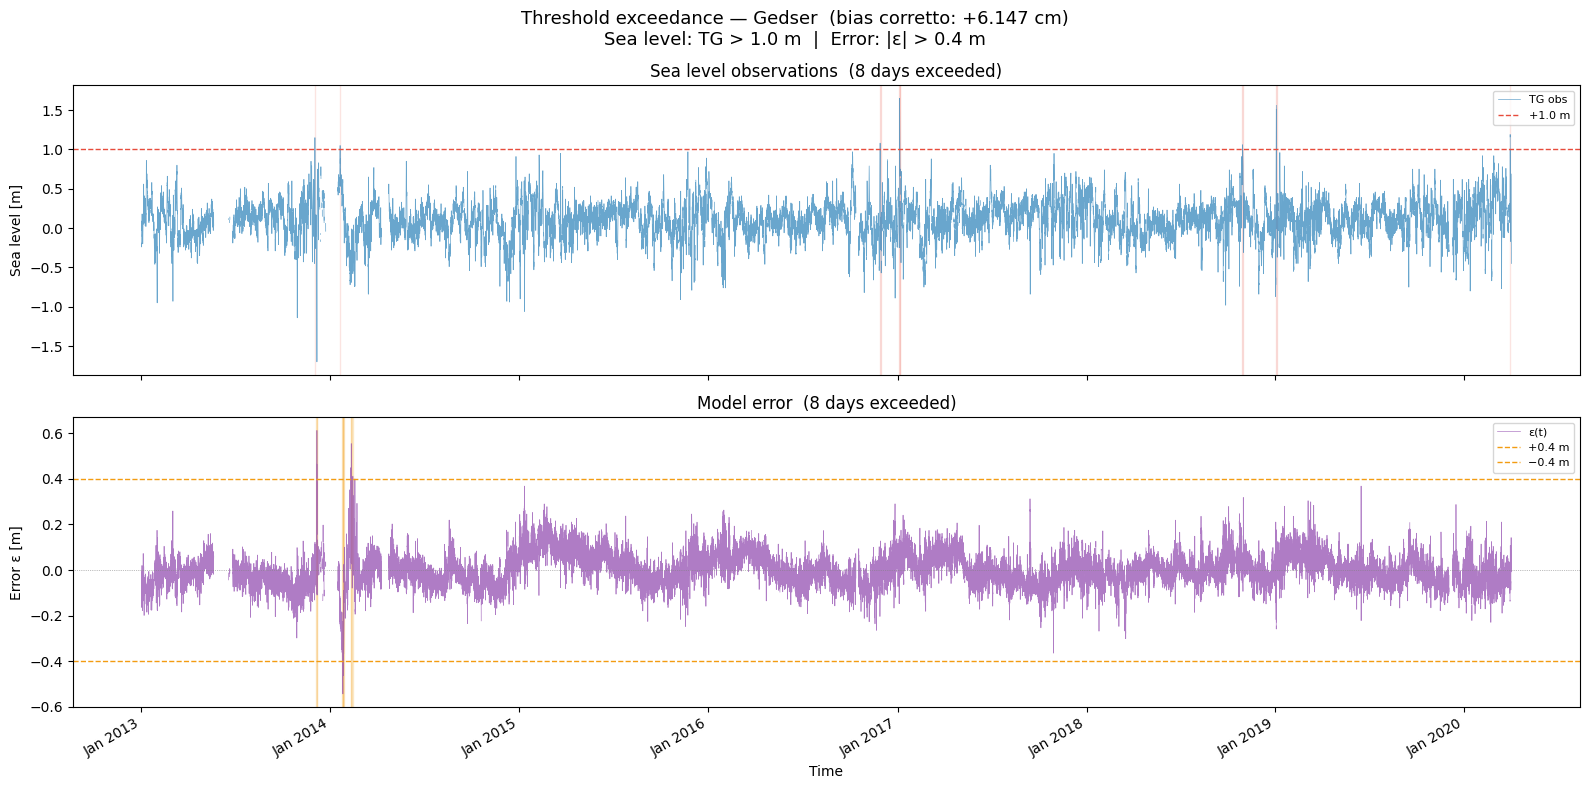

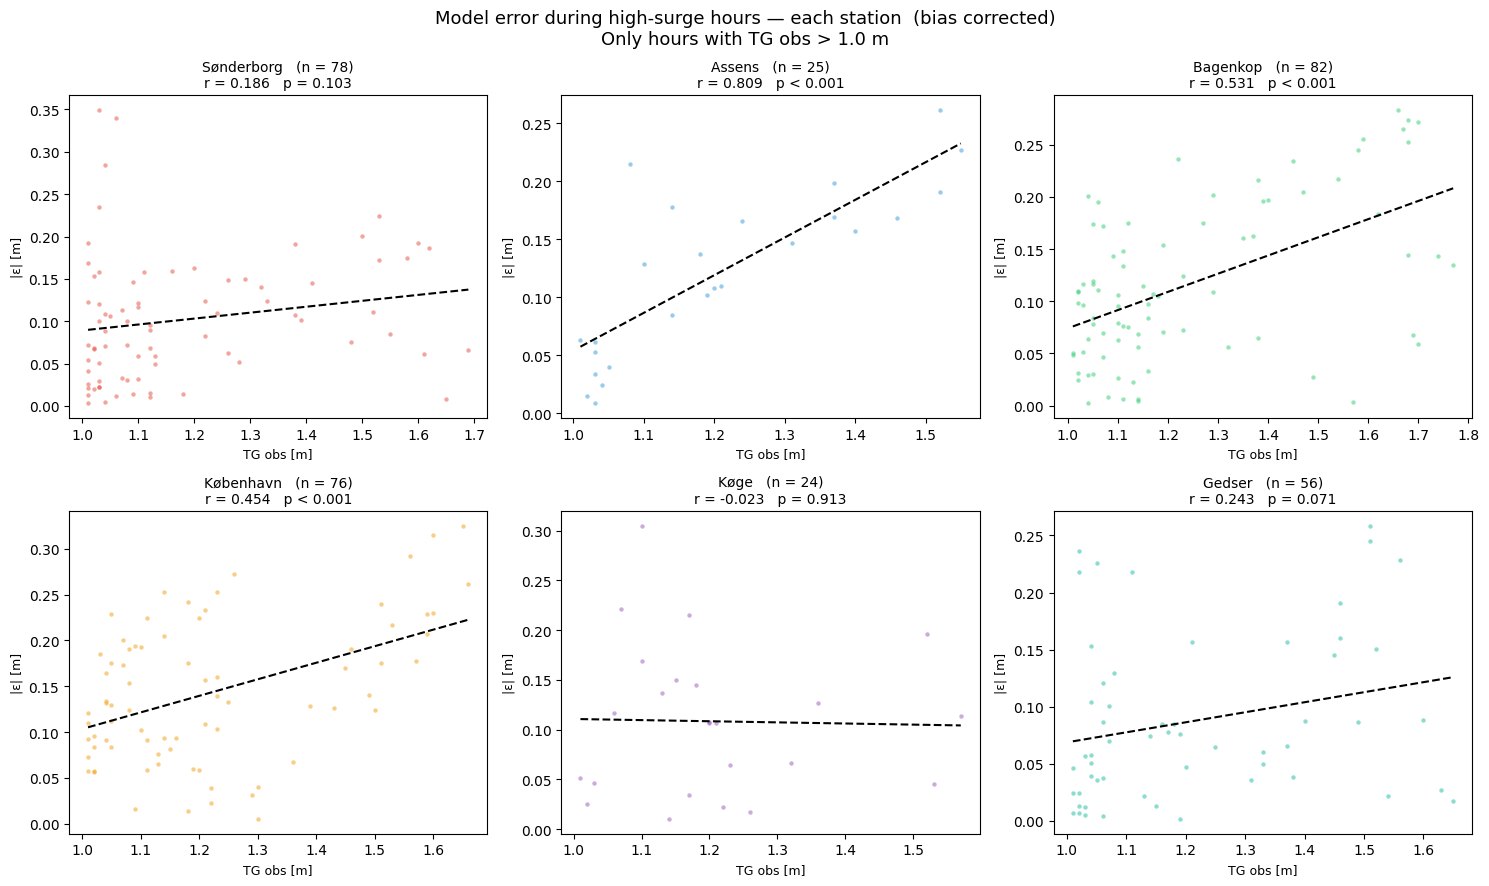

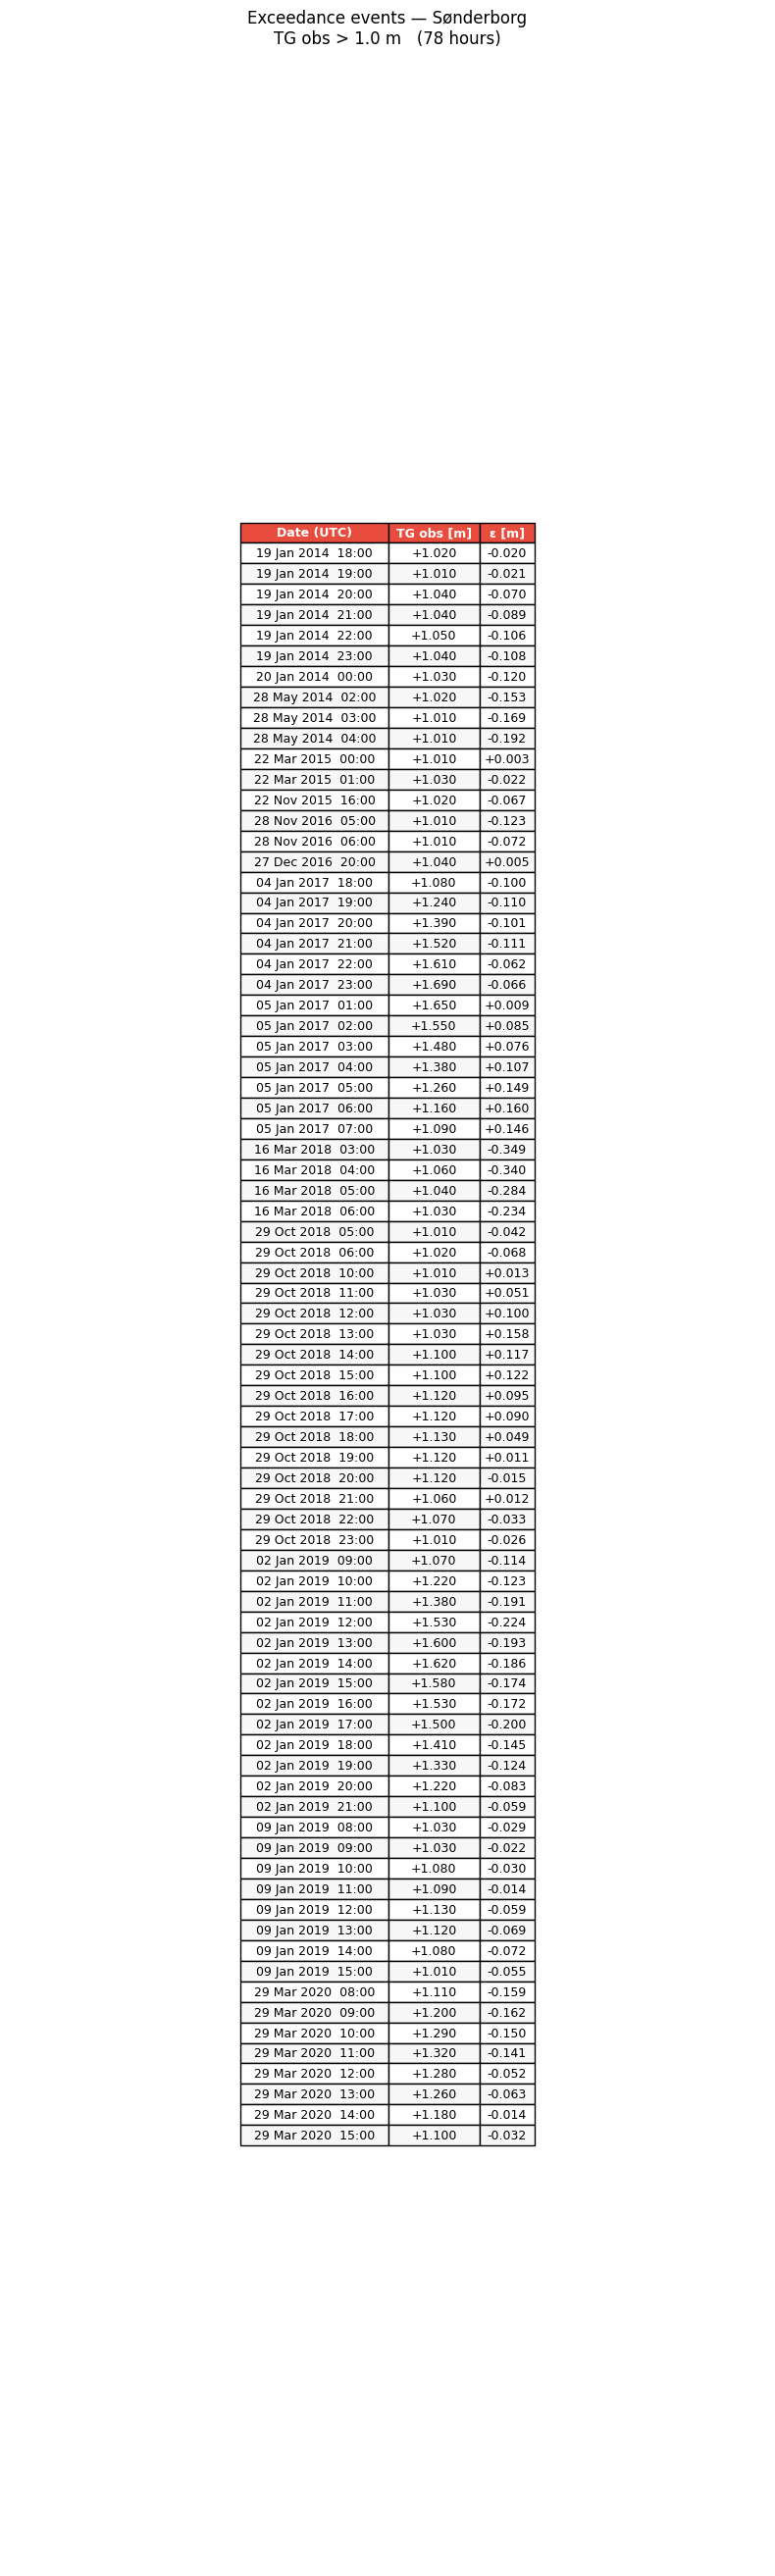

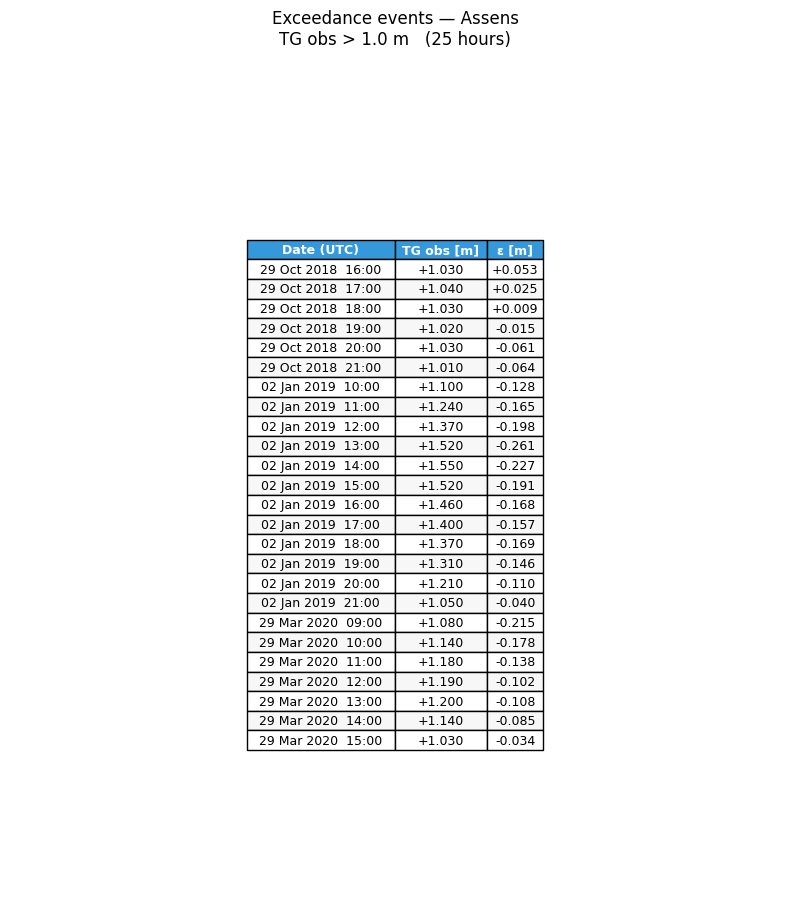

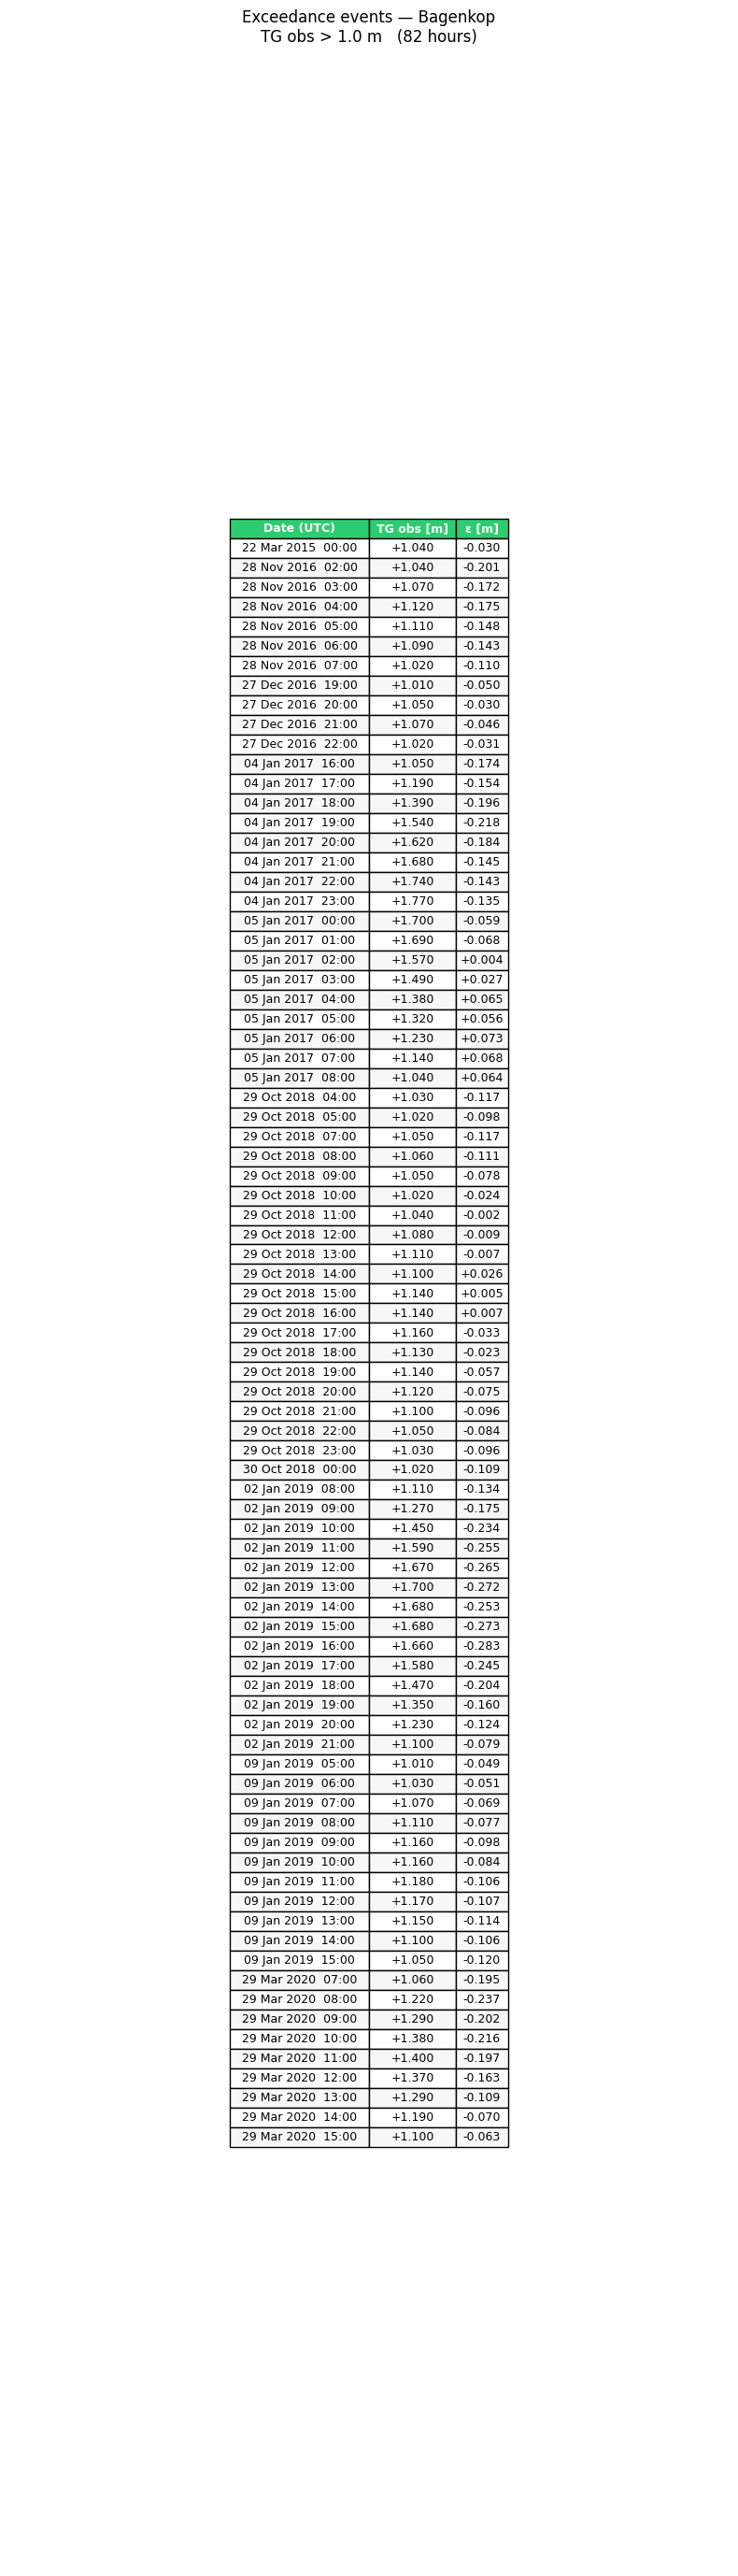

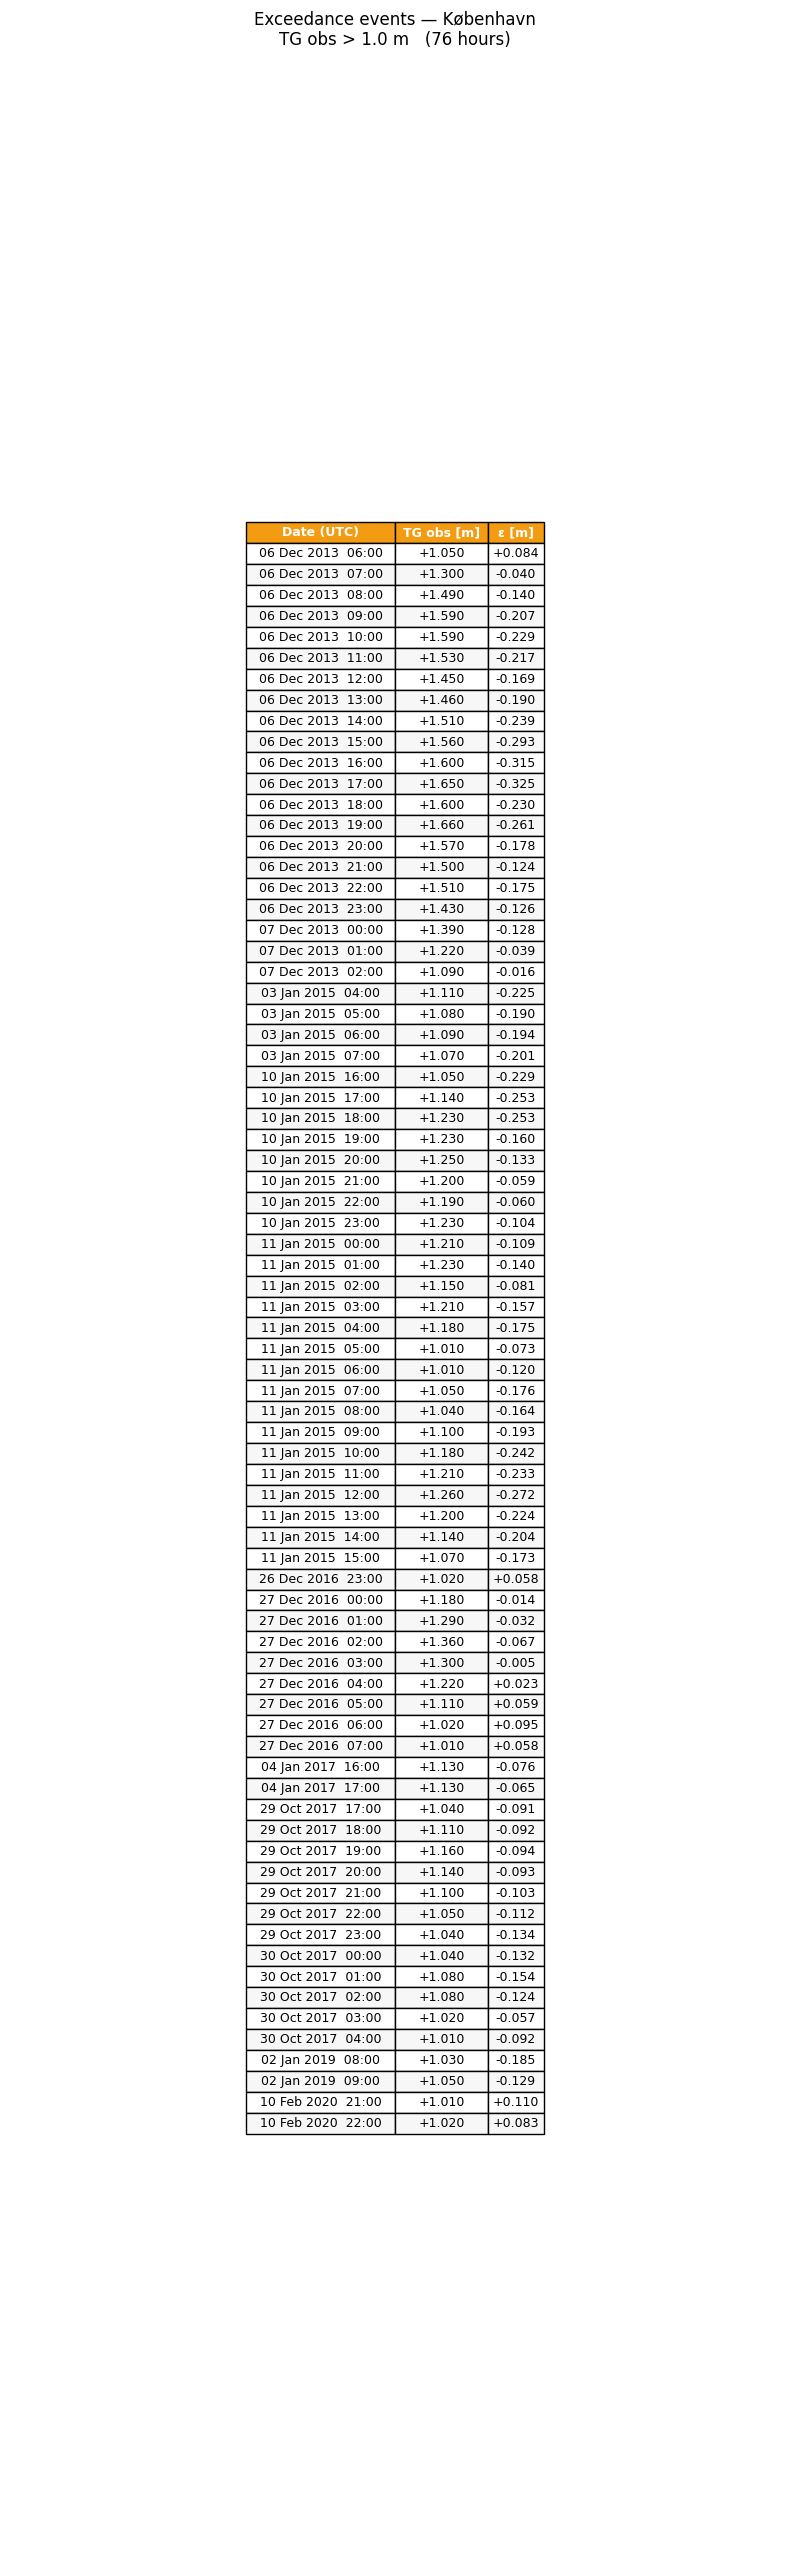

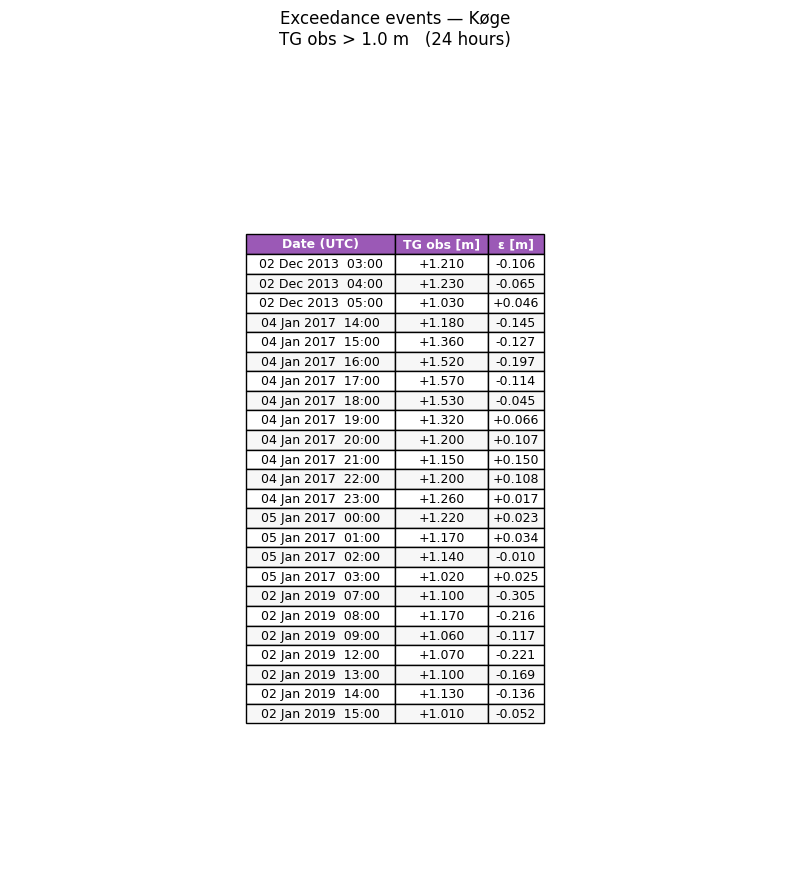

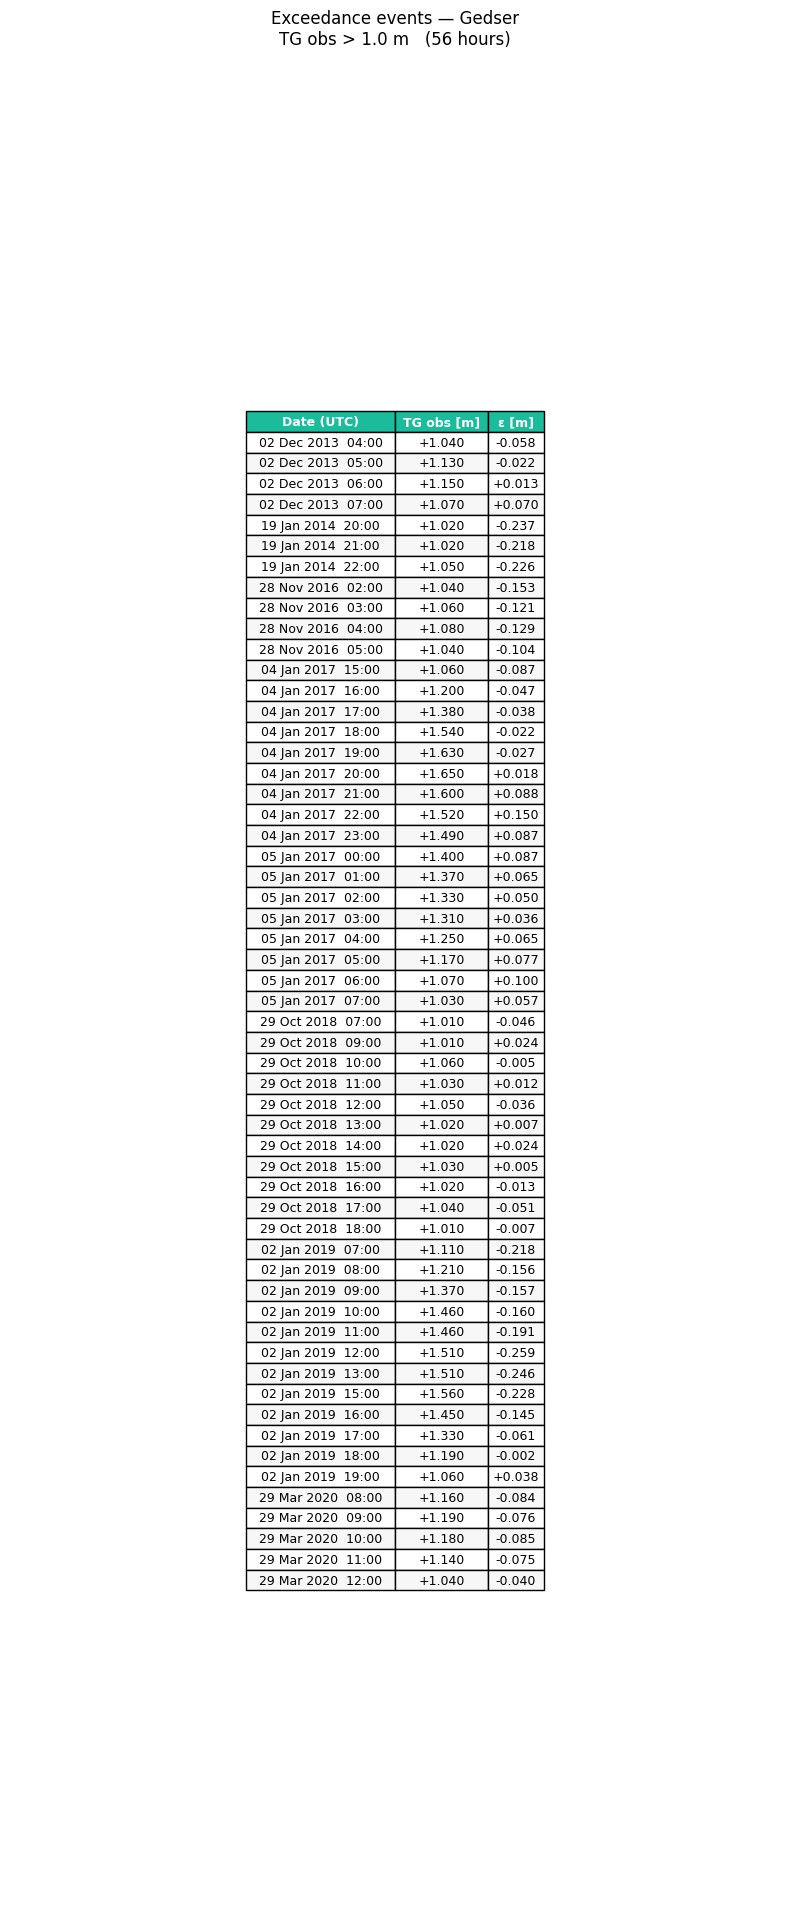

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# ════════════════════════════════════════════════════════════════════════
#  USER PARAMETERS
# ════════════════════════════════════════════════════════════════════════
THRESH_SL  = 1.00   # [m]  sea-level threshold  (tg_obs_m > THRESH_SL, positive only)
THRESH_ERR = 0.40   # [m]  error threshold for Figure 1 shading only

REMOVE_BIAS = True   # True  → sottrae la media temporale di (Model − TG)
                      # False → lascia l'errore invariato

DATA_DIR = "/Users/nicolocaron/Desktop/MASTER PROJECT/data/per_station"

STATIONS = [
    {"file": "station_26473_Sonderborg.parquet", "name": "Sønderborg"},
    {"file": "station_28366_Assens.parquet",      "name": "Assens"},
    {"file": "station_28548_Bagenkop.parquet",    "name": "Bagenkop"},
    {"file": "station_30336_Kobenhavn.parquet",   "name": "København"},
    {"file": "station_30478_Koge.parquet",        "name": "Køge"},
    {"file": "station_31616_Gedser.parquet",      "name": "Gedser"},
]

COLORS = ["#E74C3C", "#3498DB", "#2ECC71", "#F39C12", "#9B59B6", "#1ABC9C"]

def _apply_bias(df):
    """Compute error_m and optionally subtract mean bias."""
    df["error_m"] = df["forcoast_p82_m"] - df["tg_obs_m"]
    mean_bias = df["error_m"].mean()
    if REMOVE_BIAS:
        df["error_m"] -= mean_bias
    return df, mean_bias
# ════════════════════════════════════════════════════════════════════════

# ── Figure 1: time series for Gedser ────────────────────────────────────
df_thr = pd.read_parquet(f"{DATA_DIR}/station_31616_Gedser.parquet")
df_thr = df_thr.sort_values("time").reset_index(drop=True)
df_thr, mean_bias_thr = _apply_bias(df_thr)
bias_tag_thr = f"(bias corretto: {mean_bias_thr*100:+.3f} cm)" if REMOVE_BIAS else "(bias NON rimosso)"
print(f"[REMOVE_BIAS={REMOVE_BIAS}]  Gedser bias: {mean_bias_thr*100:+.3f} cm")
df_thr["date"]    = pd.to_datetime(df_thr["time"]).dt.date
df_thr["exc_sl"]  = df_thr["tg_obs_m"] > THRESH_SL          # positive only
df_thr["exc_err"] = df_thr["error_m"].abs()  > THRESH_ERR

daily = (
    df_thr.groupby("date")
    .agg(
        exc_sl  = ("exc_sl",  "any"),
        exc_err = ("exc_err", "any"),
        sl_max  = ("tg_obs_m", "max"),
        err_max = ("error_m",  lambda x: x.abs().max()),
    )
    .reset_index()
)
days_sl  = daily[daily["exc_sl"]].copy()
days_err = daily[daily["exc_err"]].copy()

combined = pd.merge(
    daily[["date", "exc_sl", "sl_max"]],
    daily[["date", "exc_err", "err_max"]],
    on="date", how="outer"
).fillna({"exc_sl": False, "exc_err": False})
combined = combined[combined["exc_sl"] | combined["exc_err"]].copy()
combined = combined.sort_values("date").reset_index(drop=True)
combined["date"] = pd.to_datetime(combined["date"])

t_all = pd.to_datetime(df_thr["time"])
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(
    f"Threshold exceedance — Gedser  {bias_tag_thr}\n"
    f"Sea level: TG > {THRESH_SL} m  |  Error: |ε| > {THRESH_ERR} m",
    fontsize=13,
)
ax = axes[0]
ax.plot(t_all, df_thr["tg_obs_m"], color="#2980B9", lw=0.5, alpha=0.7, label="TG obs")
ax.axhline(THRESH_SL, color="#E74C3C", lw=1.0, ls="--", label=f"+{THRESH_SL} m")
for d in combined[combined["exc_sl"]]["date"]:
    ax.axvspan(d, d + pd.Timedelta(days=1), color="#E74C3C", alpha=0.15)
ax.set_ylabel("Sea level [m]")
ax.legend(fontsize=8, loc="upper right")
ax.set_title(f"Sea level observations  ({len(days_sl)} days exceeded)")

ax = axes[1]
ax.plot(t_all, df_thr["error_m"], color="#8E44AD", lw=0.5, alpha=0.7, label="ε(t)")
ax.axhline( THRESH_ERR, color="#F39C12", lw=1.0, ls="--", label=f"+{THRESH_ERR} m")
ax.axhline(-THRESH_ERR, color="#F39C12", lw=1.0, ls="--", label=f"−{THRESH_ERR} m")
ax.axhline(0, color="grey", lw=0.5, ls=":")
for d in combined[combined["exc_err"]]["date"]:
    ax.axvspan(d, d + pd.Timedelta(days=1), color="#F39C12", alpha=0.20)
ax.set_ylabel("Error ε [m]")
ax.set_xlabel("Time")
ax.legend(fontsize=8, loc="upper right")
ax.set_title(f"Model error  ({len(days_err)} days exceeded)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════
#  FIGURE 2 — 2×3 grid: one scatter per station
# ════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 9))
fig2.suptitle(
    f"Model error during high-surge hours — each station" + ("  (bias corrected)" if REMOVE_BIAS else "") + "\n"
    f"Only hours with TG obs > {THRESH_SL} m",
    fontsize=13,
)
axes2 = axes2.flatten()

summary_rows = []

for i, (st, col) in enumerate(zip(STATIONS, COLORS)):
    ax = axes2[i]

    df_st = pd.read_parquet(f"{DATA_DIR}/{st['file']}")
    df_st = df_st.sort_values("time").reset_index(drop=True)
    df_st, _ = _apply_bias(df_st)

    exc = df_st[df_st["tg_obs_m"] > THRESH_SL][["tg_obs_m", "error_m"]].dropna().copy()
    exc["abs_err"] = exc["error_m"].abs()

    if len(exc) < 2:
        ax.set_title(f"{st['name']}  — no data")
        ax.set_visible(False)
        continue

    r_st, p_st = pearsonr(exc["tg_obs_m"], exc["abs_err"])
    summary_rows.append({"station": st["name"], "n_hours": len(exc), "r": r_st, "pval": p_st})

    ax.scatter(exc["tg_obs_m"], exc["abs_err"], color=col, s=10, alpha=0.5, linewidths=0)

    m_st = np.polyfit(exc["tg_obs_m"], exc["abs_err"], 1)
    x_fit = np.linspace(exc["tg_obs_m"].min(), exc["tg_obs_m"].max(), 200)
    ax.plot(x_fit, np.polyval(m_st, x_fit), color="black", lw=1.5, ls="--")

    p_label = "< 0.001" if p_st < 0.001 else f"= {p_st:.3f}"
    ax.set_title(
        f"{st['name']}   (n = {len(exc)})\n"
        f"r = {r_st:.3f}   p {p_label}",
        fontsize=10,
    )
    ax.set_xlabel("TG obs [m]", fontsize=9)
    ax.set_ylabel("|ε| [m]", fontsize=9)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════
#  FIGURE 3 — Matplotlib table: hours where TG obs > threshold (positive)
#  One table per station (one figure per station)
#  Columns: Date | TG obs [m] | ε [m]
# ════════════════════════════════════════════════════════════════════════
for st, col in zip(STATIONS, COLORS):
    df_st = pd.read_parquet(f"{DATA_DIR}/{st['file']}")
    df_st = df_st.sort_values("time").reset_index(drop=True)
    df_st, _ = _apply_bias(df_st)

    # Keep only hours where TG obs > threshold (positive only), sorted chronologically
    exc_tbl = df_st[df_st["tg_obs_m"] > THRESH_SL][["time", "tg_obs_m", "error_m"]].dropna().copy()
    exc_tbl = exc_tbl.sort_values("time").reset_index(drop=True)

    if exc_tbl.empty:
        continue

    # Format columns
    dates_str  = pd.to_datetime(exc_tbl["time"]).dt.strftime("%d %b %Y  %H:%M")
    tg_str     = exc_tbl["tg_obs_m"].map(lambda v: f"{v:+.3f}")
    err_str    = exc_tbl["error_m"].map(lambda v: f"{v:+.3f}")

    table_data = list(zip(dates_str, tg_str, err_str))
    col_labels = ["Date (UTC)", "TG obs [m]", "ε [m]"]

    n_rows = len(table_data)
    fig_h  = max(2.0, 0.32 * n_rows + 1.0)   # dynamic height

    fig_tbl, ax_tbl = plt.subplots(figsize=(8, fig_h))
    ax_tbl.axis("off")
    fig_tbl.suptitle(
        f"Exceedance events — {st['name']}\n"
        f"TG obs > {THRESH_SL} m   ({n_rows} hours)",
        fontsize=12, y=1.01,
    )

    tbl = ax_tbl.table(
        cellText=table_data,
        colLabels=col_labels,
        cellLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.auto_set_column_width([0, 1, 2])

    # Header style
    for j in range(3):
        tbl[0, j].set_facecolor(col)
        tbl[0, j].set_text_props(color="white", fontweight="bold")

    # Alternating row shading
    for row_idx in range(1, n_rows + 1):
        bg = "#F7F7F7" if row_idx % 2 == 0 else "white"
        for j in range(3):
            tbl[row_idx, j].set_facecolor(bg)

    plt.tight_layout()
    plt.show()



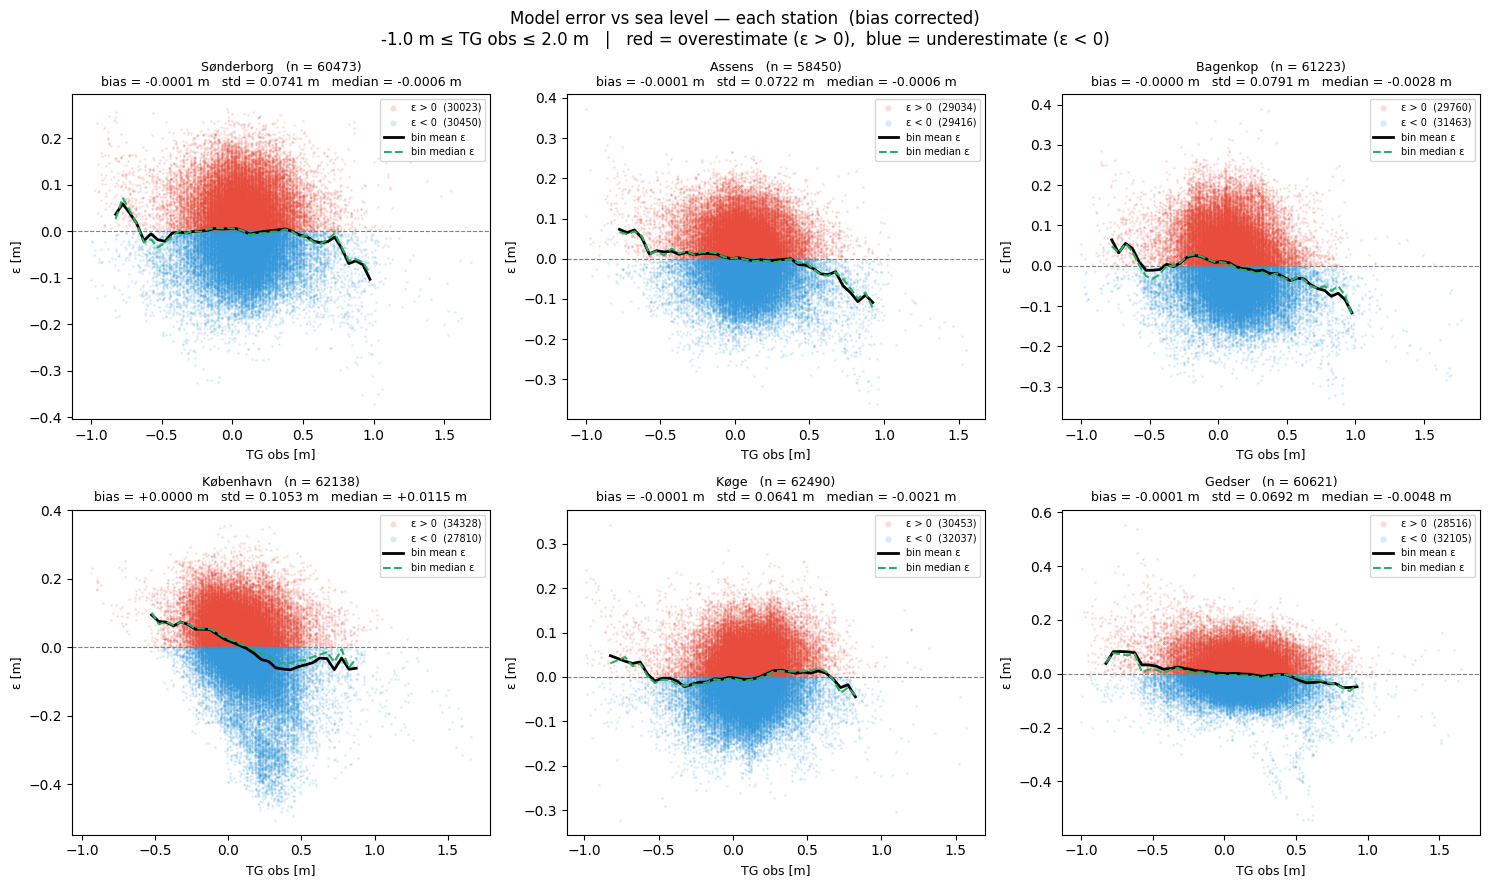

In [6]:

# ════════════════════════════════════════════════════════════════════════
#  USER PARAMETERS — normal-conditions range
# ════════════════════════════════════════════════════════════════════════
RANGE_LOW  = -1.00   # [m]  lower bound of TG obs window (inclusive)
RANGE_HIGH =  2.00   # [m]  upper bound of TG obs window (inclusive)
BIN_WIDTH  =  0.05   # [m]  bin width for the running-mean/median lines

REMOVE_BIAS = True   # True  → sottrae la media temporale di (Model − TG)
                      # False → lascia l'errore invariato

def _apply_bias_scatter(df):
    """Compute error_m and optionally subtract mean bias."""
    df["error_m"] = df["forcoast_p82_m"] - df["tg_obs_m"]
    mean_bias = df["error_m"].mean()
    if REMOVE_BIAS:
        df["error_m"] -= mean_bias
    return df, mean_bias
# ════════════════════════════════════════════════════════════════════════

# ────────────────────────────────────────────────────────────────────────
#  FIGURE A — 2×3 scatter grid: ε (signed) vs TG obs
#  colour = overestimate (ε > 0, red) vs underestimate (ε < 0, blue)
#  black solid  = bin-mean of ε   (conditional bias)
#  green dashed = bin-median of ε (robust conditional bias)
# ────────────────────────────────────────────────────────────────────────
figA, axesA = plt.subplots(2, 3, figsize=(15, 9))
figA.suptitle(
    f"Model error vs sea level — each station" + ("  (bias corrected)" if REMOVE_BIAS else "") + "\n"
    f"{RANGE_LOW} m ≤ TG obs ≤ {RANGE_HIGH} m   |   "
    f"red = overestimate (ε > 0),  blue = underestimate (ε < 0)",
    fontsize=12,
)
axesA = axesA.flatten()

for i, (st, col) in enumerate(zip(STATIONS, COLORS)):
    ax = axesA[i]

    df_st = pd.read_parquet(f"{DATA_DIR}/{st['file']}")
    df_st = df_st.sort_values("time").reset_index(drop=True)
    df_st, _ = _apply_bias_scatter(df_st)

    mask = (df_st["tg_obs_m"] >= RANGE_LOW) & (df_st["tg_obs_m"] <= RANGE_HIGH)
    sub  = df_st[mask][["tg_obs_m", "error_m"]].dropna().copy()

    if len(sub) < 2:
        ax.set_visible(False)
        continue

    over  = sub["error_m"] >= 0   # model overestimates sea level
    under = sub["error_m"] <  0   # model underestimates sea level

    ax.scatter(sub.loc[over,  "tg_obs_m"], sub.loc[over,  "error_m"],
               s=3, alpha=0.20, color="#E74C3C", linewidths=0, label=f"ε > 0  ({over.sum()})")
    ax.scatter(sub.loc[under, "tg_obs_m"], sub.loc[under, "error_m"],
               s=3, alpha=0.20, color="#3498DB", linewidths=0, label=f"ε < 0  ({under.sum()})")

    # Conditional bias: mean(ε) and median(ε) per TG bin
    bin_edges   = np.arange(RANGE_LOW, RANGE_HIGH + BIN_WIDTH, BIN_WIDTH)
    bin_means   = []
    bin_medians = []
    valid_mids  = []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        bucket = sub.loc[(sub["tg_obs_m"] >= lo) & (sub["tg_obs_m"] < hi), "error_m"]
        if len(bucket) >= 30:
            bin_means.append(bucket.mean())
            bin_medians.append(bucket.median())
            valid_mids.append((lo + hi) / 2)
    if valid_mids:
        ax.plot(valid_mids, bin_means,   color="black",   lw=2.0, ls="-",
                zorder=5, label="bin mean ε")
        ax.plot(valid_mids, bin_medians, color="#27AE60", lw=1.5, ls="--",
                zorder=5, label="bin median ε")

    ax.axhline(0, color="grey", lw=0.8, ls="--")

    bias_total   = sub["error_m"].mean()
    std_total    = sub["error_m"].std()
    median_total = sub["error_m"].median()
    ax.set_title(
        f"{st['name']}   (n = {len(sub)})\n"
        f"bias = {bias_total:+.4f} m   std = {std_total:.4f} m   median = {median_total:+.4f} m",
        fontsize=9,
    )
    ax.set_xlabel("TG obs [m]", fontsize=9)
    ax.set_ylabel("ε [m]", fontsize=9)
    ax.legend(fontsize=7, markerscale=2.5)

plt.tight_layout()
plt.show()
